# Unsupervised Learning Trading Strategy

## Step 1: Retrieving 8 years of historical S&P500 stock data

In [ ]:
conda install pandas --force-reinstall

In [ ]:
#!pip install PyPortfolioOpt
#!pip install scikit-learn
#!pip install pandas_datareader
#!pip install statsmodels
#!pip install matplotlib
#!pip install pandas pandas-ta
#!pip install html5lib

In [1]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as wb
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
import warnings
import requests
warnings.filterwarnings('ignore')

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)
sp500 = tables[0]
sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-')
symbols_list = sp500['Symbol'].unique().tolist()

end_date = '2026-05-19'
start_date = pd.to_datetime(end_date) - pd.DateOffset(365*8)

df = yf.download(tickers=symbols_list,
                 start=start_date,
                 end=end_date).stack()

[*********************100%***********************]  503 of 503 completed


In [3]:
df

Price                   Close        High         Low        Open      Volume
Date       Ticker                                                            
2018-05-21 A        61.733898   62.148278   60.914544   60.980469   4527300.0
           AAPL     44.208561   44.594970   44.038917   44.295738  73603200.0
           ABBV     75.545097   76.270464   75.345972   76.092678   5797300.0
           ABT      53.871498   54.201094   53.593944   53.776088   4610100.0
           ACGL     25.230507   25.259035   24.780415   25.037158   1282800.0
...                       ...         ...         ...         ...         ...
2026-05-18 XYZ      70.629997   71.800003   69.540001   69.779999   4806000.0
           YUM     152.309998  153.199997  150.259995  150.449997   1418300.0
           ZBH      85.139999   86.269997   84.150002   84.239998   2303200.0
           ZBRA    260.059998  263.489990  254.860001  261.059998   1067700.0
           ZTS      77.720001   77.959999   74.199997   74.199997   8848300.0

[991693 rows x 5 columns]

## Step 2: Garman-Klass Volatility calculation

### Uses Open, High, Low, Close prices to calculate volatility of asset

In [30]:
df['garman_klass_vol'] = ((np.log(df['High']) - np.log(df['Low']))**2)/2 - (2*np.log(2)-1)*((np.log(df['Close']) - np.log(df['Open']))**2)
df

Price                   Close        High         Low        Open      Volume  \
Date       Ticker                                                               
2018-05-21 A        61.733898   62.148278   60.914544   60.980469   4527300.0   
           AAPL     44.208561   44.594970   44.038917   44.295738  73603200.0   
           ABBV     75.545097   76.270464   75.345972   76.092678   5797300.0   
           ABT      53.871498   54.201094   53.593944   53.776088   4610100.0   
           ACGL     25.230507   25.259035   24.780415   25.037158   1282800.0   
...                       ...         ...         ...         ...         ...   
2026-05-18 XYZ      70.629997   71.800003   69.540001   69.779999   4806000.0   
           YUM     152.309998  153.199997  150.259995  150.449997   1418300.0   
           ZBH      85.139999   86.269997   84.150002   84.239998   2303200.0   
           ZBRA    260.059998  263.489990  254.860001  261.059998   1067700.0   
           ZTS      77.720001   77.959999   74.199997   74.199997   8848300.0   

Price                    rsi    bb_low    bb_mid   bb_high       atr  \
Date       Ticker                                                      
2018-05-21 A             NaN       NaN       NaN       NaN       NaN   
           AAPL          NaN       NaN       NaN       NaN       NaN   
           ABBV          NaN       NaN       NaN       NaN       NaN   
           ABT           NaN       NaN       NaN       NaN       NaN   
           ACGL          NaN       NaN       NaN       NaN       NaN   
...                      ...       ...       ...       ...       ...   
2026-05-18 XYZ     54.636020  4.243557  4.279953  4.316350 -0.669419   
           YUM     44.488753  5.003147  5.052521  5.101894  1.948175   
           ZBH     45.866385  4.351797  4.454012  4.556227 -0.211569   
           ZBRA    66.019333  5.337420  5.451821  5.566221  0.432055   
           ZTS     23.480986  4.207328  4.601312  4.995297  0.928863   

Price                  macd  dollar_volume  garman_klass_vol  
Date       Ticker                                             
2018-05-21 A            NaN     279.487877          0.000143  
           AAPL         NaN    3253.891553          0.000077  
           ABBV         NaN     437.957593          0.000054  
           ABT          NaN     248.352993          0.000062  
           ACGL         NaN      32.365694          0.000160  
...                     ...            ...               ...  
2026-05-18 XYZ     0.313871     339.447767          0.000455  
           YUM    -1.606299     216.021270          0.000129  
           ZBH    -0.890518     196.094447          0.000266  
           ZBRA    0.912822     277.666059          0.000549  
           ZTS    -4.425070     687.689887          0.000392  

[991693 rows x 13 columns]

## Step 3: RSI

### Momentum indicator popularly used. We will keep this metric unnormalized to help formation of clusters in K-means clustering step

<Axes: xlabel='Date'>

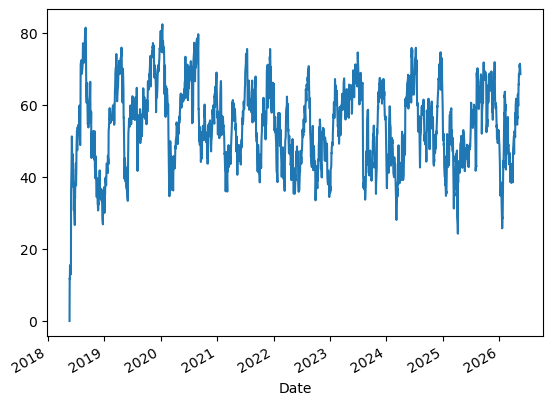

In [33]:
df['rsi'] = df.groupby(level=1)['Close'].transform(lambda x: pandas_ta.rsi(close=x, length=20))
df
df.xs('AAPL', level=1)['rsi'].plot()

## Step 4: Bollinger Bands

### Used to measure market volatility and help indentify dynamic bands which adjust based on asset and market volatility

In [34]:
#pandas_ta.bbands(close=df.xs('AAPL', level=1)['Close'], length=20)

df['bb_low'] = df.groupby(level=1)['Close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,0])
df['bb_mid'] = df.groupby(level=1)['Close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,1])
df['bb_high'] = df.groupby(level=1)['Close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,2])
df

Price                   Close        High         Low        Open      Volume  \
Date       Ticker                                                               
2018-05-21 A        61.733898   62.148278   60.914544   60.980469   4527300.0   
           AAPL     44.208561   44.594970   44.038917   44.295738  73603200.0   
           ABBV     75.545097   76.270464   75.345972   76.092678   5797300.0   
           ABT      53.871498   54.201094   53.593944   53.776088   4610100.0   
           ACGL     25.230507   25.259035   24.780415   25.037158   1282800.0   
...                       ...         ...         ...         ...         ...   
2026-05-18 XYZ      70.629997   71.800003   69.540001   69.779999   4806000.0   
           YUM     152.309998  153.199997  150.259995  150.449997   1418300.0   
           ZBH      85.139999   86.269997   84.150002   84.239998   2303200.0   
           ZBRA    260.059998  263.489990  254.860001  261.059998   1067700.0   
           ZTS      77.720001   77.959999   74.199997   74.199997   8848300.0   

Price                    rsi    bb_low    bb_mid   bb_high       atr  \
Date       Ticker                                                      
2018-05-21 A             NaN       NaN       NaN       NaN       NaN   
           AAPL          NaN       NaN       NaN       NaN       NaN   
           ABBV          NaN       NaN       NaN       NaN       NaN   
           ABT           NaN       NaN       NaN       NaN       NaN   
           ACGL          NaN       NaN       NaN       NaN       NaN   
...                      ...       ...       ...       ...       ...   
2026-05-18 XYZ     54.636020  4.243557  4.279953  4.316350 -0.669419   
           YUM     44.488753  5.003147  5.052521  5.101894  1.948175   
           ZBH     45.866385  4.351797  4.454012  4.556227 -0.211569   
           ZBRA    66.019333  5.337420  5.451821  5.566221  0.432055   
           ZTS     23.480986  4.207328  4.601312  4.995297  0.928863   

Price                  macd  dollar_volume  garman_klass_vol  
Date       Ticker                                             
2018-05-21 A            NaN     279.487877          0.000143  
           AAPL         NaN    3253.891553          0.000077  
           ABBV         NaN     437.957593          0.000054  
           ABT          NaN     248.352993          0.000062  
           ACGL         NaN      32.365694          0.000160  
...                     ...            ...               ...  
2026-05-18 XYZ     0.313871     339.447767          0.000455  
           YUM    -1.606299     216.021270          0.000129  
           ZBH    -0.890518     196.094447          0.000266  
           ZBRA    0.912822     277.666059          0.000549  
           ZTS    -4.425070     687.689887          0.000392  

[991693 rows x 13 columns]

## Step 5: Average True Range

### Measures price volatility over a specific period, in our case we pick 2 weeks (14 days)

In [35]:
# pandas_ta.atr(high=df['High'],
#               low=df['Low'],
#               close=df['Close'],
#               length=14)

def compute_atr(stock_data):
    atr = pandas_ta.atr(high=stock_data['High'],
                        low=stock_data['Low'],
                        close=stock_data['Close'],
                        length=14)
    return atr.sub(atr.mean()).div(atr.std())
    
df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)
df

Price                   Close        High         Low        Open      Volume  \
Date       Ticker                                                               
2018-05-21 A        61.733898   62.148278   60.914544   60.980469   4527300.0   
           AAPL     44.208561   44.594970   44.038917   44.295738  73603200.0   
           ABBV     75.545097   76.270464   75.345972   76.092678   5797300.0   
           ABT      53.871498   54.201094   53.593944   53.776088   4610100.0   
           ACGL     25.230507   25.259035   24.780415   25.037158   1282800.0   
...                       ...         ...         ...         ...         ...   
2026-05-18 XYZ      70.629997   71.800003   69.540001   69.779999   4806000.0   
           YUM     152.309998  153.199997  150.259995  150.449997   1418300.0   
           ZBH      85.139999   86.269997   84.150002   84.239998   2303200.0   
           ZBRA    260.059998  263.489990  254.860001  261.059998   1067700.0   
           ZTS      77.720001   77.959999   74.199997   74.199997   8848300.0   

Price                    rsi    bb_low    bb_mid   bb_high       atr  \
Date       Ticker                                                      
2018-05-21 A             NaN       NaN       NaN       NaN       NaN   
           AAPL          NaN       NaN       NaN       NaN       NaN   
           ABBV          NaN       NaN       NaN       NaN       NaN   
           ABT           NaN       NaN       NaN       NaN       NaN   
           ACGL          NaN       NaN       NaN       NaN       NaN   
...                      ...       ...       ...       ...       ...   
2026-05-18 XYZ     54.636020  4.243557  4.279953  4.316350 -0.669419   
           YUM     44.488753  5.003147  5.052521  5.101894  1.948175   
           ZBH     45.866385  4.351797  4.454012  4.556227 -0.211569   
           ZBRA    66.019333  5.337420  5.451821  5.566221  0.432055   
           ZTS     23.480986  4.207328  4.601312  4.995297  0.928863   

Price                  macd  dollar_volume  garman_klass_vol  
Date       Ticker                                             
2018-05-21 A            NaN     279.487877          0.000143  
           AAPL         NaN    3253.891553          0.000077  
           ABBV         NaN     437.957593          0.000054  
           ABT          NaN     248.352993          0.000062  
           ACGL         NaN      32.365694          0.000160  
...                     ...            ...               ...  
2026-05-18 XYZ     0.313871     339.447767          0.000455  
           YUM    -1.606299     216.021270          0.000129  
           ZBH    -0.890518     196.094447          0.000266  
           ZBRA    0.912822     277.666059          0.000549  
           ZTS    -4.425070     687.689887          0.000392  

[991693 rows x 13 columns]

## Step 6: MACD Indicator

### Finds two moving averages of a stock and calculates the difference between them, helps determine momentum, trend direction and potential buy or sell

In [36]:
def compute_macd(close):
    macd = pandas_ta.macd(close=close, length=20).iloc[:,0]
    return macd.sub(macd.mean()).div(macd.std())

df['macd'] = df.groupby(level=1, group_keys=False)['Close'].apply(compute_macd)
df

Price                   Close        High         Low        Open      Volume  \
Date       Ticker                                                               
2018-05-21 A        61.733898   62.148278   60.914544   60.980469   4527300.0   
           AAPL     44.208561   44.594970   44.038917   44.295738  73603200.0   
           ABBV     75.545097   76.270464   75.345972   76.092678   5797300.0   
           ABT      53.871498   54.201094   53.593944   53.776088   4610100.0   
           ACGL     25.230507   25.259035   24.780415   25.037158   1282800.0   
...                       ...         ...         ...         ...         ...   
2026-05-18 XYZ      70.629997   71.800003   69.540001   69.779999   4806000.0   
           YUM     152.309998  153.199997  150.259995  150.449997   1418300.0   
           ZBH      85.139999   86.269997   84.150002   84.239998   2303200.0   
           ZBRA    260.059998  263.489990  254.860001  261.059998   1067700.0   
           ZTS      77.720001   77.959999   74.199997   74.199997   8848300.0   

Price                    rsi    bb_low    bb_mid   bb_high       atr  \
Date       Ticker                                                      
2018-05-21 A             NaN       NaN       NaN       NaN       NaN   
           AAPL          NaN       NaN       NaN       NaN       NaN   
           ABBV          NaN       NaN       NaN       NaN       NaN   
           ABT           NaN       NaN       NaN       NaN       NaN   
           ACGL          NaN       NaN       NaN       NaN       NaN   
...                      ...       ...       ...       ...       ...   
2026-05-18 XYZ     54.636020  4.243557  4.279953  4.316350 -0.669419   
           YUM     44.488753  5.003147  5.052521  5.101894  1.948175   
           ZBH     45.866385  4.351797  4.454012  4.556227 -0.211569   
           ZBRA    66.019333  5.337420  5.451821  5.566221  0.432055   
           ZTS     23.480986  4.207328  4.601312  4.995297  0.928863   

Price                  macd  dollar_volume  garman_klass_vol  
Date       Ticker                                             
2018-05-21 A            NaN     279.487877          0.000143  
           AAPL         NaN    3253.891553          0.000077  
           ABBV         NaN     437.957593          0.000054  
           ABT          NaN     248.352993          0.000062  
           ACGL         NaN      32.365694          0.000160  
...                     ...            ...               ...  
2026-05-18 XYZ     0.313871     339.447767          0.000455  
           YUM    -1.606299     216.021270          0.000129  
           ZBH    -0.890518     196.094447          0.000266  
           ZBRA    0.912822     277.666059          0.000549  
           ZTS    -4.425070     687.689887          0.000392  

[991693 rows x 13 columns]

## Step 7: Dollar Volume

In [ ]:
### Measure of total monetary capital exchanged in an asset, reveals true financial backing of an asset

In [37]:
df['dollar_volume'] = (df['Close'] * df['Volume'])/1e6
df

Price                   Close        High         Low        Open      Volume  \
Date       Ticker                                                               
2018-05-21 A        61.733898   62.148278   60.914544   60.980469   4527300.0   
           AAPL     44.208561   44.594970   44.038917   44.295738  73603200.0   
           ABBV     75.545097   76.270464   75.345972   76.092678   5797300.0   
           ABT      53.871498   54.201094   53.593944   53.776088   4610100.0   
           ACGL     25.230507   25.259035   24.780415   25.037158   1282800.0   
...                       ...         ...         ...         ...         ...   
2026-05-18 XYZ      70.629997   71.800003   69.540001   69.779999   4806000.0   
           YUM     152.309998  153.199997  150.259995  150.449997   1418300.0   
           ZBH      85.139999   86.269997   84.150002   84.239998   2303200.0   
           ZBRA    260.059998  263.489990  254.860001  261.059998   1067700.0   
           ZTS      77.720001   77.959999   74.199997   74.199997   8848300.0   

Price                    rsi    bb_low    bb_mid   bb_high       atr  \
Date       Ticker                                                      
2018-05-21 A             NaN       NaN       NaN       NaN       NaN   
           AAPL          NaN       NaN       NaN       NaN       NaN   
           ABBV          NaN       NaN       NaN       NaN       NaN   
           ABT           NaN       NaN       NaN       NaN       NaN   
           ACGL          NaN       NaN       NaN       NaN       NaN   
...                      ...       ...       ...       ...       ...   
2026-05-18 XYZ     54.636020  4.243557  4.279953  4.316350 -0.669419   
           YUM     44.488753  5.003147  5.052521  5.101894  1.948175   
           ZBH     45.866385  4.351797  4.454012  4.556227 -0.211569   
           ZBRA    66.019333  5.337420  5.451821  5.566221  0.432055   
           ZTS     23.480986  4.207328  4.601312  4.995297  0.928863   

Price                  macd  dollar_volume  garman_klass_vol  
Date       Ticker                                             
2018-05-21 A            NaN     279.487877          0.000143  
           AAPL         NaN    3253.891553          0.000077  
           ABBV         NaN     437.957593          0.000054  
           ABT          NaN     248.352993          0.000062  
           ACGL         NaN      32.365694          0.000160  
...                     ...            ...               ...  
2026-05-18 XYZ     0.313871     339.447767          0.000455  
           YUM    -1.606299     216.021270          0.000129  
           ZBH    -0.890518     196.094447          0.000266  
           ZBRA    0.912822     277.666059          0.000549  
           ZTS    -4.425070     687.689887          0.000392  

[991693 rows x 13 columns]

## Step 8: Aggregate to monthly level, filter top 150 most liquid stocks for every month

In [38]:
last_columns = [c for c in df.columns.unique(0) if c not in ['dollar_volume', 'Volume', 'Open', 'High', 'Low']]

data = (pd.concat([df.unstack('Ticker')['dollar_volume'].resample('M').mean().stack('Ticker').to_frame('dollar_volume'),
          df.unstack()[last_columns].resample('M').last().stack('Ticker')],
          axis=1))
data = data.dropna()
data

dollar_volume       Close        rsi    bb_low    bb_mid  \
Date       Ticker                                                             
2018-06-30 A          184.939614   58.239902  28.360364  4.055483  4.113998   
           AAPL      4460.148445   43.614815  37.643749  3.777370  3.815845   
           ABBV       532.092123   65.887741  29.246658  4.182647  4.246821   
           ABT        273.951052   52.900070  26.059302  3.977296  4.007812   
           ACGL        57.054461   25.160774  47.326211  3.244996  3.281931   
...                          ...         ...        ...       ...       ...   
2026-05-31 XYZ        447.852190   70.629997  54.636020  4.243557  4.279953   
           YUM        253.703074  152.309998  44.488753  5.003147  5.052521   
           ZBH        185.974126   85.139999  45.866385  4.351797  4.454012   
           ZBRA       259.269029  260.059998  66.019333  5.337420  5.451821   
           ZTS        943.999898   77.720001  23.480986  4.207328  4.601312   

                    bb_high       atr      macd  garman_klass_vol  
Date       Ticker                                                  
2018-06-30 A       4.172513 -1.680130 -0.457269          0.000103  
           AAPL    3.854320 -1.604941 -0.454741          0.000252  
           ABBV    4.310995 -0.921087 -1.255737          0.000205  
           ABT     4.038328 -1.842607 -0.393564          0.000094  
           ACGL    3.318866 -1.333514 -0.359874          0.000106  
...                     ...       ...       ...               ...  
2026-05-31 XYZ     4.316350 -0.669419  0.313871          0.000455  
           YUM     5.101894  1.948175 -1.606299          0.000129  
           ZBH     4.556227 -0.211569 -0.890518          0.000266  
           ZBRA    5.566221  0.432055  0.912822          0.000549  
           ZTS     4.995297  0.928863 -4.425070          0.000392  

[47380 rows x 9 columns]

## Step 9: Calculate 5 year rolling average of dollar vol for each stock before filtering

In [40]:
#data['dollar_volume'] = (data['dollar_volume'].unstack('Ticker').rolling(5*12, min_periods=1).mean().stack().values)

data['dollar_volume_rank'] = (data.groupby('Date')['dollar_volume'].rank(ascending=False))

data = data[data['dollar_volume_rank']<150].drop(['dollar_volume', 'dollar_volume_rank'], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 14304 entries, (Timestamp('2018-06-30 00:00:00'), 'AAPL') to (Timestamp('2026-05-31 00:00:00'), 'XYZ')
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Close             14304 non-null  float64
 1   rsi               14304 non-null  float64
 2   bb_low            14304 non-null  float64
 3   bb_mid            14304 non-null  float64
 4   bb_high           14304 non-null  float64
 5   atr               14304 non-null  float64
 6   macd              14304 non-null  float64
 7   garman_klass_vol  14304 non-null  float64
dtypes: float64(8)
memory usage: 958.9+ KB


## Step 10: Calculate Monthly Return for different time horizons as Features

In [ ]:
### Helps figure out how an asset balances risk and volatility across time, gives perspective on potential liquidity if you were to invest in some asset and wanted your money out quick or long

In [41]:
def calculate_returns(df): 
    outlier_cutoff = 0.005
    lags = [1,2,3,6,9,12]
    
    for lag in lags:
        df[f'return_{lag}m'] = (df['Close'].pct_change(lag).pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                                                       upper=x.quantile(1-outlier_cutoff)))
                                      .add(1)
                                      .pow(1/lag)
                                      .sub(1))
    return df
data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()
data.info()
#data

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11969 entries, (Timestamp('2019-06-30 00:00:00'), 'AAPL') to (Timestamp('2026-05-31 00:00:00'), 'XYZ')
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Close             11969 non-null  float64
 1   rsi               11969 non-null  float64
 2   bb_low            11969 non-null  float64
 3   bb_mid            11969 non-null  float64
 4   bb_high           11969 non-null  float64
 5   atr               11969 non-null  float64
 6   macd              11969 non-null  float64
 7   garman_klass_vol  11969 non-null  float64
 8   return_1m         11969 non-null  float64
 9   return_2m         11969 non-null  float64
 10  return_3m         11969 non-null  float64
 11  return_6m         11969 non-null  float64
 12  return_9m         11969 non-null  float64
 13  return_12m        11969 non-null  float64
dtypes: float64(14)
memory usage: 1.3+ MB


## Step 11: Download Fama-French Factors and Calc Rolling Factor Betas

### Market-wide indicators of systematic forces that influence asset prices

In [51]:
factor_data = wb.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='2010')[0].drop('RF', axis=1)


factor_data.index = factor_data.index.to_timestamp()
factor_data = factor_data.resample('M').last().div(100)


factor_data = factor_data.join(data['return_1m']).sort_index()

factor_data.xs('AAPL', level=1).head()
factor_data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11682 entries, (Timestamp('2019-06-30 00:00:00'), 'AAPL') to (Timestamp('2026-03-31 00:00:00'), 'XYZ')
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Mkt-RF     11682 non-null  float64
 1   SMB        11682 non-null  float64
 2   HML        11682 non-null  float64
 3   RMW        11682 non-null  float64
 4   CMA        11682 non-null  float64
 5   return_1m  11682 non-null  float64
dtypes: float64(6)
memory usage: 619.0+ KB


In [43]:
factor_data.xs('MSFT', level=1).head()

,Mkt-RF,SMB,HML,RMW,CMA,return_1m
Date,,,,,,
2019-06-30,0.0699,0.0019,-0.0064,0.0045,-0.0055,0.083118
2019-07-31,0.0122,-0.0182,0.0050,-0.0013,0.0037,0.017244
2019-08-31,-0.0255,-0.0325,-0.0477,0.0053,-0.0062,0.015037
2019-09-30,0.0142,0.0029,0.0676,0.0182,0.0338,0.008487
2019-10-31,0.0207,0.0025,-0.0192,0.0043,-0.0103,0.031216


## Step 12: Filter out stocks that have < 10 month data to remove them

In [52]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]
factor_data = factor_data[factor_data.index.get_level_values('Ticker').isin(valid_stocks.index)]
factor_data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11644 entries, (Timestamp('2019-06-30 00:00:00'), 'AAPL') to (Timestamp('2026-03-31 00:00:00'), 'XYZ')
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Mkt-RF     11644 non-null  float64
 1   SMB        11644 non-null  float64
 2   HML        11644 non-null  float64
 3   RMW        11644 non-null  float64
 4   CMA        11644 non-null  float64
 5   return_1m  11644 non-null  float64
dtypes: float64(6)
memory usage: 617.1+ KB


## Step 13: Calculate Rolling Factor Betas

In [ ]:
### Basically run regression of all asset prices against the fama french factors to measure sensitivity (betas) of each asset against those factors

In [53]:
betas = (factor_data.groupby(level=1, group_keys=False)
         .apply(lambda x: RollingOLS(endog=x['return_1m'],
                                     exog=sm.add_constant(x.drop('return_1m', axis=1)),
                                     window=min(24, x.shape[0]),
                                     min_nobs = len(x.columns)+1).fit(params_only=True).params.drop('const', axis=1)))
betas

Mkt-RF       SMB       HML        RMW        CMA
Date       Ticker                                                    
2019-06-30 AAPL         NaN       NaN       NaN        NaN        NaN
           ABBV         NaN       NaN       NaN        NaN        NaN
           ABT          NaN       NaN       NaN        NaN        NaN
           ACN          NaN       NaN       NaN        NaN        NaN
           ADBE         NaN       NaN       NaN        NaN        NaN
...                     ...       ...       ...        ...        ...
2026-03-31 WDC    -2.711346  5.882686 -2.491070  17.339396  18.315648
           WFC     1.179108 -0.356437  0.886619  -1.210075  -0.386736
           WMT     1.093785 -0.180958  0.310525   0.552059  -0.390488
           XOM     0.041451  0.094863  1.080851  -0.177067   0.598733
           XYZ     0.446150  1.833771 -2.546990  -2.203875   1.432634

[11644 rows x 5 columns]

In [64]:
#data = (data.join(betas.groupby('Ticker').shift()))
#data
#data = data.drop(columns=['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA'])
#factors = ['Mkt-RF','SMB','HML','RMW','CMA']
#data.loc[:, factors] = data.groupby('Ticker', group_keys=False)[factors].apply(lambda x: x.fillna(x.mean()))
#data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11652 entries, (Timestamp('2019-06-30 00:00:00'), 'AAPL') to (Timestamp('2026-05-31 00:00:00'), 'XYZ')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rsi               11652 non-null  float64
 1   bb_low            11652 non-null  float64
 2   bb_mid            11652 non-null  float64
 3   bb_high           11652 non-null  float64
 4   atr               11652 non-null  float64
 5   macd              11652 non-null  float64
 6   garman_klass_vol  11652 non-null  float64
 7   return_1m         11652 non-null  float64
 8   return_2m         11652 non-null  float64
 9   return_3m         11652 non-null  float64
 10  return_6m         11652 non-null  float64
 11  return_9m         11652 non-null  float64
 12  return_12m        11652 non-null  float64
 13  Mkt-RF            11652 non-null  float64
 14  SMB               11652 non-null  float64
 15  HML       

## FINAL DATASET FOR TRAINING OUR MODEL

In [66]:
#data = data.drop('Close', axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11652 entries, (Timestamp('2019-06-30 00:00:00'), 'AAPL') to (Timestamp('2026-05-31 00:00:00'), 'XYZ')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rsi               11652 non-null  float64
 1   bb_low            11652 non-null  float64
 2   bb_mid            11652 non-null  float64
 3   bb_high           11652 non-null  float64
 4   atr               11652 non-null  float64
 5   macd              11652 non-null  float64
 6   garman_klass_vol  11652 non-null  float64
 7   return_1m         11652 non-null  float64
 8   return_2m         11652 non-null  float64
 9   return_3m         11652 non-null  float64
 10  return_6m         11652 non-null  float64
 11  return_9m         11652 non-null  float64
 12  return_12m        11652 non-null  float64
 13  Mkt-RF            11652 non-null  float64
 14  SMB               11652 non-null  float64
 15  HML       

# K Means Clustering Algorithm Training

## Step 1: Fit a K-Means Clustering Algorithm for each month of stock data to group similar assets based on features

In [67]:
from sklearn.cluster import KMeans

In [77]:
data

rsi    bb_low    bb_mid   bb_high       atr  \
Date       Ticker                                                      
2019-06-30 AAPL    56.282118  3.776028  3.852828  3.929628 -1.444910   
           ABBV    42.046276  3.949237  4.053470  4.157702 -0.630197   
           ABT     64.665798  4.233351  4.295571  4.357792 -1.417181   
           ACN     58.459365  5.084876  5.116330  5.147784 -1.430894   
           ADBE    58.679798  5.564131  5.645850  5.727570 -1.178310   
...                      ...       ...       ...       ...       ...   
2026-05-31 WDC     61.275419  5.910164  6.097704  6.285244  6.398544   
           WFC     39.781945  4.292023  4.369298  4.446573  1.410259   
           WMT     59.614486  4.850536  4.876461  4.902386  2.597337   
           XOM     59.965740  4.967872  5.020585  5.073298  3.079989   
           XYZ     54.636020  4.243557  4.279953  4.316350 -0.669419   

                       macd  garman_klass_vol  return_1m  return_2m  \
Date       Ticker                                                     
2019-06-30 AAPL   -0.052149          0.000071   0.130519  -0.004965   
           ABBV   -0.878016          0.000223  -0.052014  -0.042929   
           ABT     0.947063          0.000088   0.104689   0.028136   
           ACN     0.248709          0.000099   0.037626   0.005732   
           ADBE    0.505814          0.000057   0.087671   0.009291   
...                     ...               ...        ...        ...   
2026-05-31 WDC     7.224934          0.003540   0.055602   0.302205   
           WFC    -1.905334          0.000112  -0.090415  -0.030712   
           WMT     1.333770          0.000083   0.012616   0.036797   
           XOM     0.147875          0.000688   0.046973  -0.024105   
           XYZ     0.313871          0.000455   0.001702   0.083349   

                   return_3m  return_6m  return_9m  return_12m    Mkt-RF  \
Date       Ticker                                                          
2019-06-30 AAPL     0.015095   0.039950  -0.013235    0.006858  1.126725   
           ABBV    -0.029421  -0.032447  -0.024888   -0.016205  0.542865   
           ABT      0.018439   0.026936   0.016743    0.028618  0.796026   
           ACN      0.019101   0.047516   0.011115    0.011659  1.110946   
           ADBE     0.034051   0.045016   0.009775    0.015908  1.424824   
...                      ...        ...        ...         ...       ...   
2026-05-31 WDC      0.179438   0.431228   0.305339    0.262850 -0.666409   
           WFC     -0.028012  -0.021914  -0.009291    0.001352  1.044047   
           WMT      0.015187   0.032825   0.036701    0.026079  0.688792   
           XOM      0.019464   0.058081   0.040997    0.040958  0.833130   
           XYZ      0.035023   0.009335  -0.013252    0.011260  2.294961   

                        SMB       HML       RMW       CMA  cluster  
Date       Ticker                                                   
2019-06-30 AAPL   -0.008796 -0.559123  0.454692  0.222180        3  
           ABBV   -0.033670  0.206616  0.206709  0.564993        0  
           ABT    -0.181598 -0.106873 -0.103314  0.842086        2  
           ACN    -0.102541 -0.195055  0.128240 -0.135453        3  
           ADBE   -0.659103 -0.104323  0.329868 -0.378854        3  
...                     ...       ...       ...       ...      ...  
2026-05-31 WDC     2.691657 -0.635357  7.656675  9.255720        2  
           WFC    -0.154817  1.394117 -0.942158 -0.881074        0  
           WMT    -0.233394 -0.300854  0.281335  0.295622        3  
           XOM    -0.126366  0.942548 -0.209904  0.346101        3  
           XYZ     0.478815 -0.190072 -2.343527 -0.197114        3  

[11652 rows x 19 columns]

In [90]:
target_rsi_values = [30,45,55,70]

initial_centroids = np.zeros((len(target_rsi_values), 18))

initial_centroids[:, 0] = target_rsi_values
initial_centroids

def get_clusters(df):
    df['cluster'] = KMeans(n_clusters=4,
                           random_state=0,
                           init=initial_centroids).fit(df).labels_
    return df

data = data.dropna().groupby('Date', group_keys=False).apply(get_clusters)
data

rsi    bb_low    bb_mid   bb_high       atr  \
Date       Ticker                                                      
2019-06-30 AAPL    56.282118  3.776028  3.852828  3.929628 -1.444910   
           ABBV    42.046276  3.949237  4.053470  4.157702 -0.630197   
           ABT     64.665798  4.233351  4.295571  4.357792 -1.417181   
           ACN     58.459365  5.084876  5.116330  5.147784 -1.430894   
           ADBE    58.679798  5.564131  5.645850  5.727570 -1.178310   
...                      ...       ...       ...       ...       ...   
2026-05-31 WDC     61.275419  5.910164  6.097704  6.285244  6.398544   
           WFC     39.781945  4.292023  4.369298  4.446573  1.410259   
           WMT     59.614486  4.850536  4.876461  4.902386  2.597337   
           XOM     59.965740  4.967872  5.020585  5.073298  3.079989   
           XYZ     54.636020  4.243557  4.279953  4.316350 -0.669419   

                       macd  garman_klass_vol  return_1m  return_2m  \
Date       Ticker                                                     
2019-06-30 AAPL   -0.052149          0.000071   0.130519  -0.004965   
           ABBV   -0.878016          0.000223  -0.052014  -0.042929   
           ABT     0.947063          0.000088   0.104689   0.028136   
           ACN     0.248709          0.000099   0.037626   0.005732   
           ADBE    0.505814          0.000057   0.087671   0.009291   
...                     ...               ...        ...        ...   
2026-05-31 WDC     7.224934          0.003540   0.055602   0.302205   
           WFC    -1.905334          0.000112  -0.090415  -0.030712   
           WMT     1.333770          0.000083   0.012616   0.036797   
           XOM     0.147875          0.000688   0.046973  -0.024105   
           XYZ     0.313871          0.000455   0.001702   0.083349   

                   return_3m  return_6m  return_9m  return_12m    Mkt-RF  \
Date       Ticker                                                          
2019-06-30 AAPL     0.015095   0.039950  -0.013235    0.006858  1.126725   
           ABBV    -0.029421  -0.032447  -0.024888   -0.016205  0.542865   
           ABT      0.018439   0.026936   0.016743    0.028618  0.796026   
           ACN      0.019101   0.047516   0.011115    0.011659  1.110946   
           ADBE     0.034051   0.045016   0.009775    0.015908  1.424824   
...                      ...        ...        ...         ...       ...   
2026-05-31 WDC      0.179438   0.431228   0.305339    0.262850 -0.666409   
           WFC     -0.028012  -0.021914  -0.009291    0.001352  1.044047   
           WMT      0.015187   0.032825   0.036701    0.026079  0.688792   
           XOM      0.019464   0.058081   0.040997    0.040958  0.833130   
           XYZ      0.035023   0.009335  -0.013252    0.011260  2.294961   

                        SMB       HML       RMW       CMA  cluster  
Date       Ticker                                                   
2019-06-30 AAPL   -0.008796 -0.559123  0.454692  0.222180        2  
           ABBV   -0.033670  0.206616  0.206709  0.564993        1  
           ABT    -0.181598 -0.106873 -0.103314  0.842086        3  
           ACN    -0.102541 -0.195055  0.128240 -0.135453        2  
           ADBE   -0.659103 -0.104323  0.329868 -0.378854        2  
...                     ...       ...       ...       ...      ...  
2026-05-31 WDC     2.691657 -0.635357  7.656675  9.255720        2  
           WFC    -0.154817  1.394117 -0.942158 -0.881074        0  
           WMT    -0.233394 -0.300854  0.281335  0.295622        2  
           XOM    -0.126366  0.942548 -0.209904  0.346101        2  
           XYZ     0.478815 -0.190072 -2.343527 -0.197114        2  

[11652 rows x 19 columns]

In [91]:
def plot_clusters(data):

    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,4] , cluster_0.iloc[:,0] , color = 'red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,4] , cluster_1.iloc[:,0] , color = 'green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,4] , cluster_2.iloc[:,0] , color = 'blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,4] , cluster_3.iloc[:,0] , color = 'black', label='cluster 3')

    plt.legend()
    plt.show()
    return

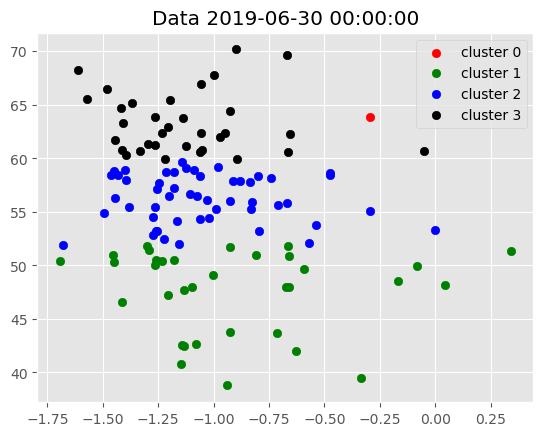

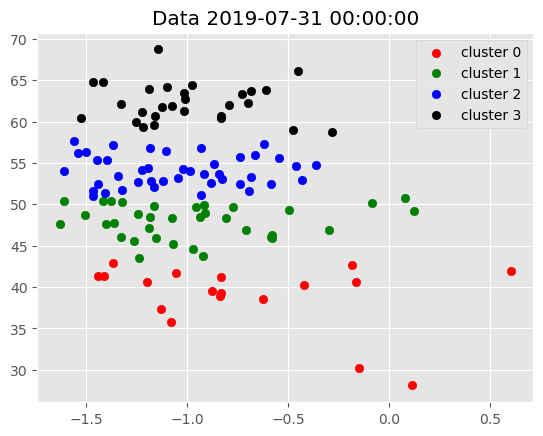

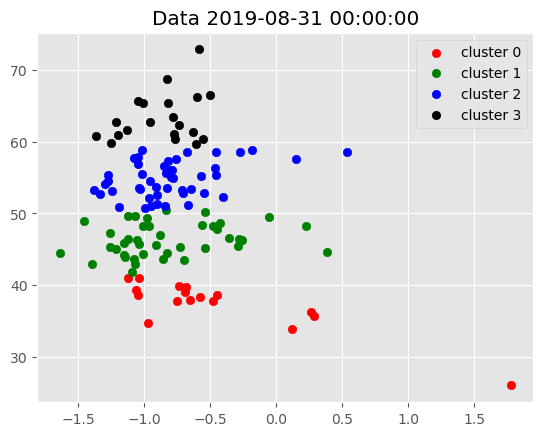

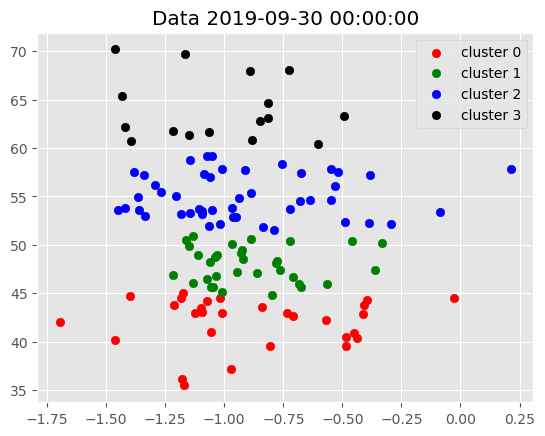

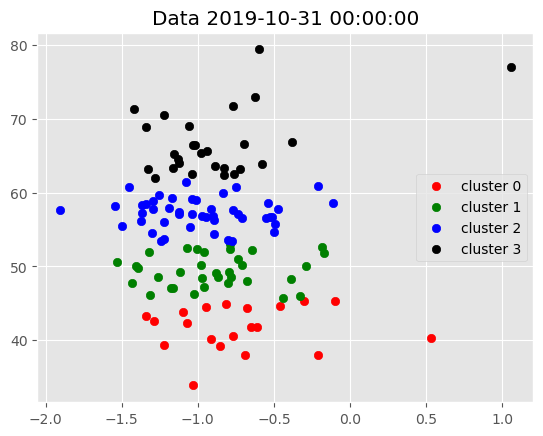

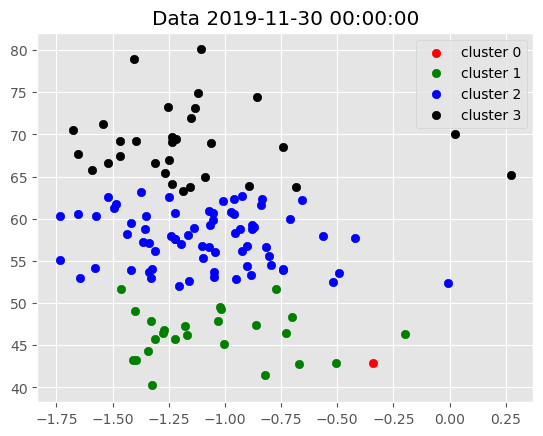

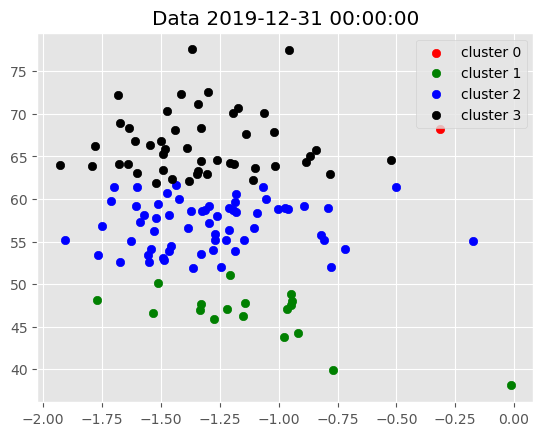

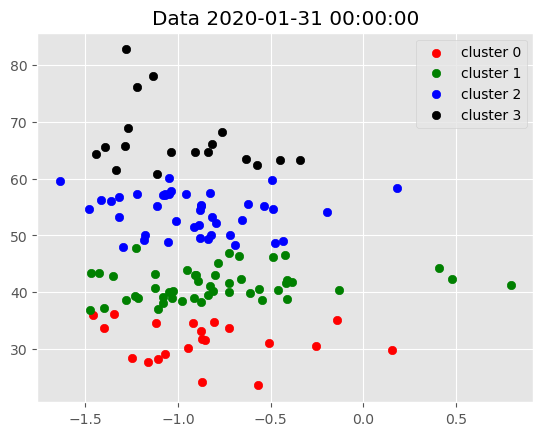

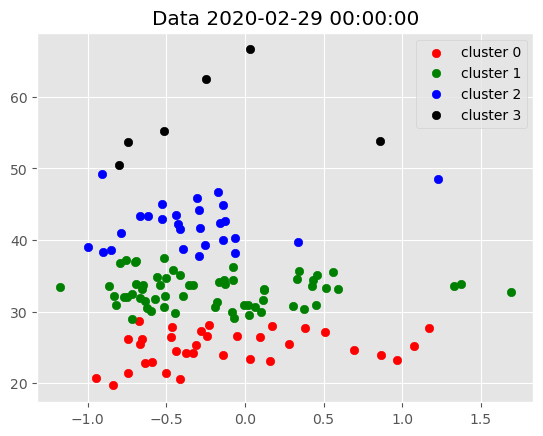

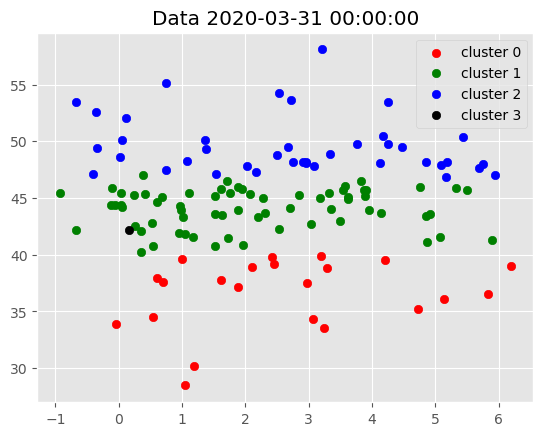

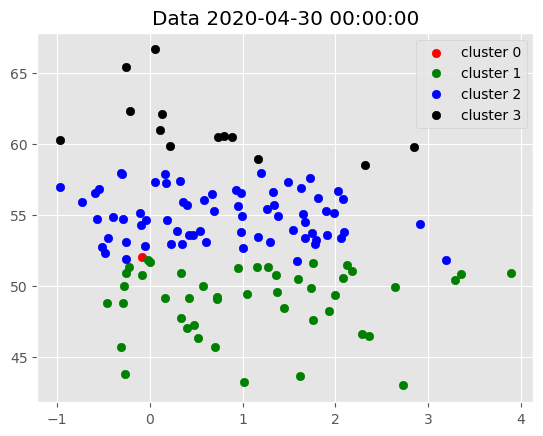

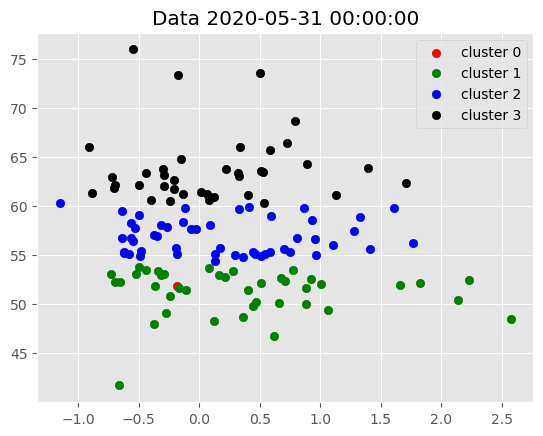

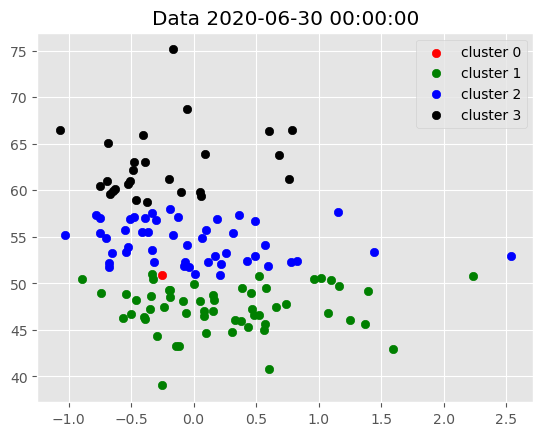

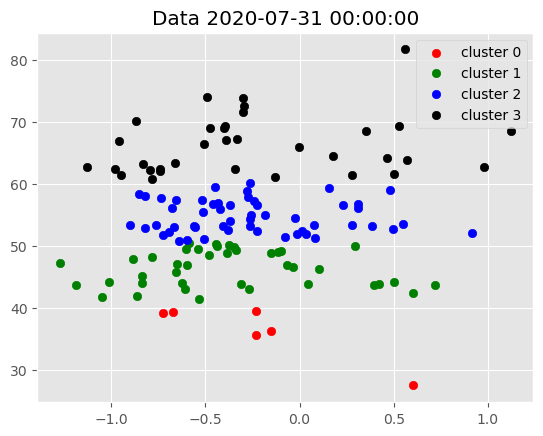

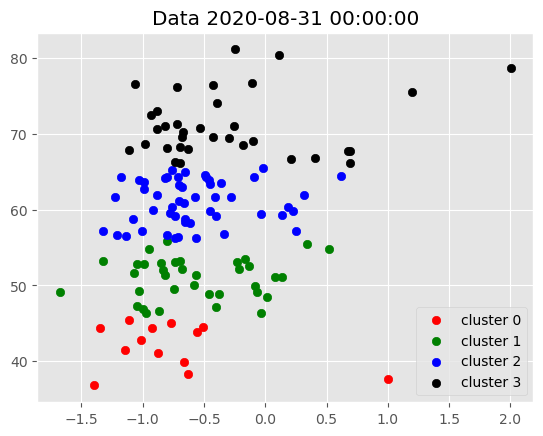

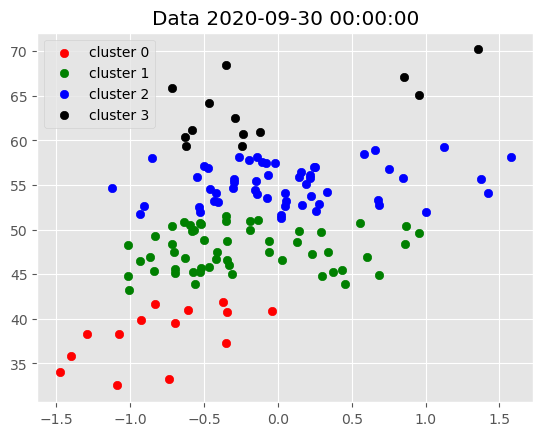

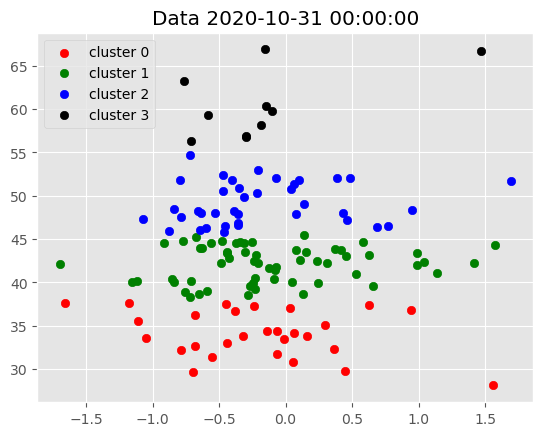

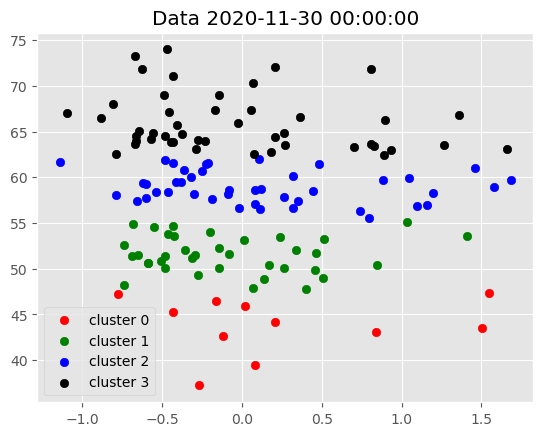

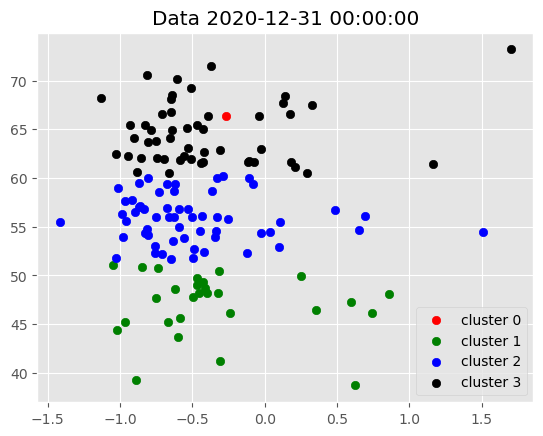

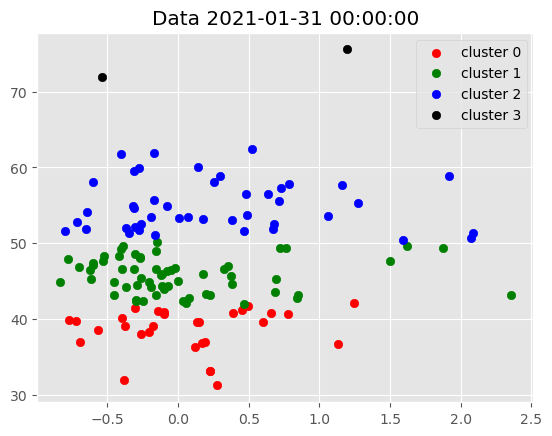

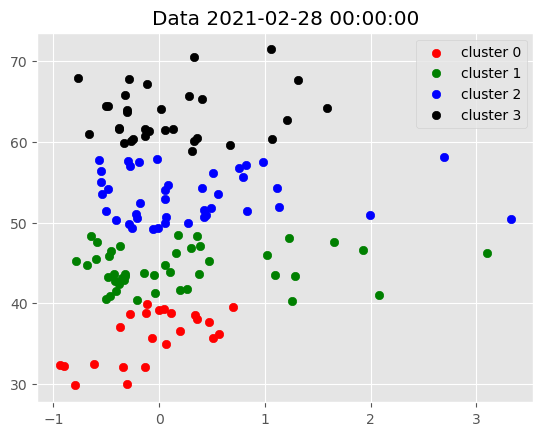

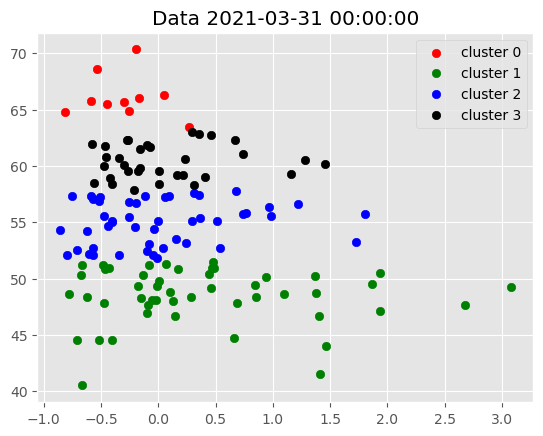

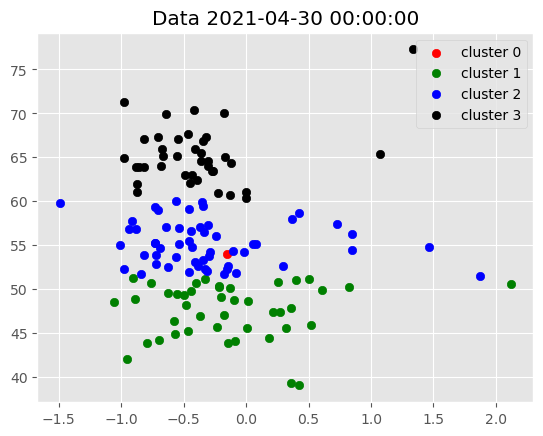

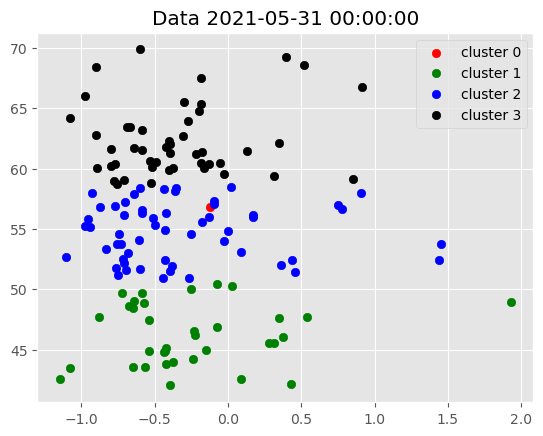

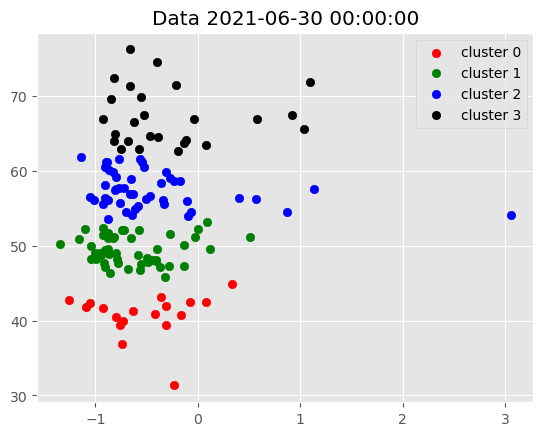

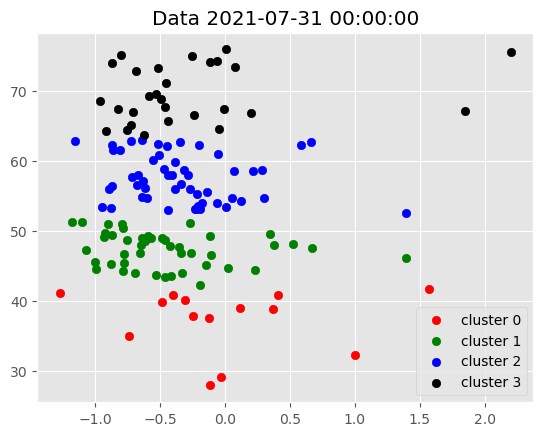

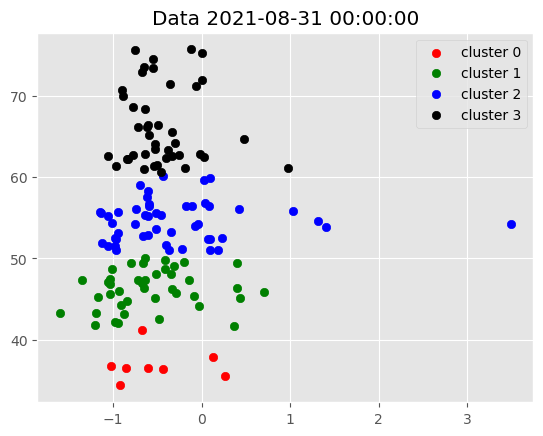

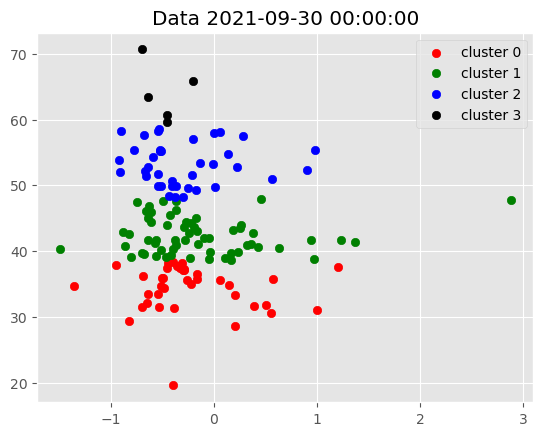

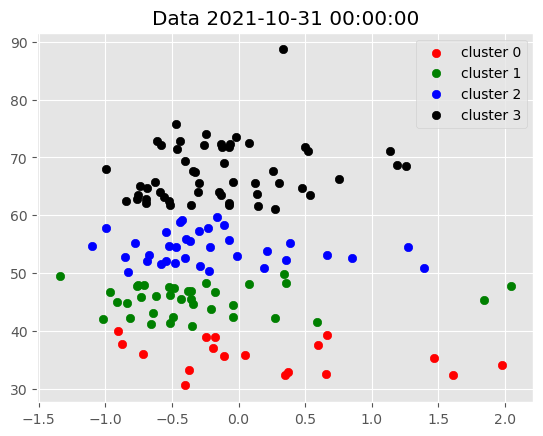

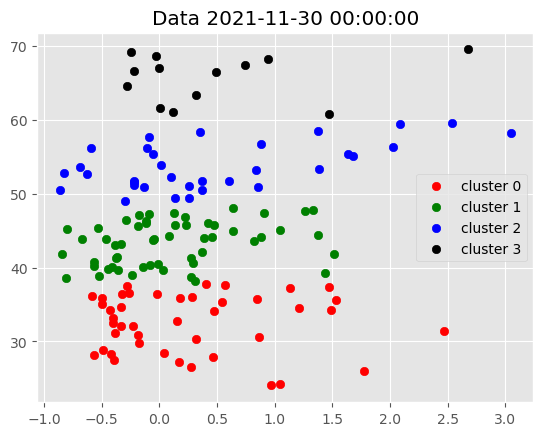

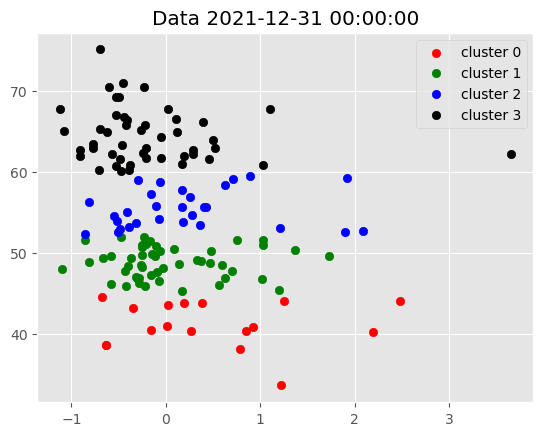

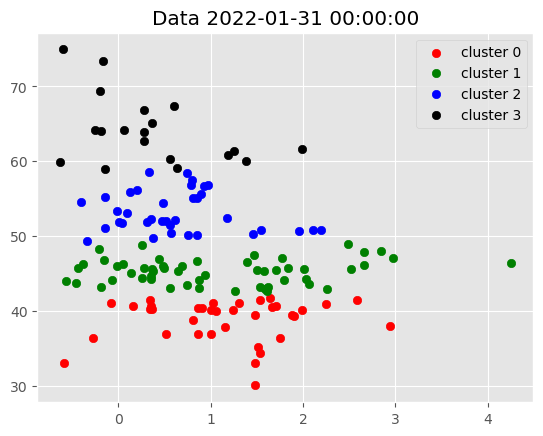

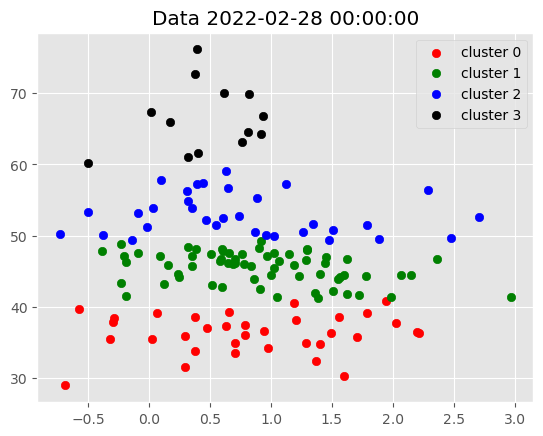

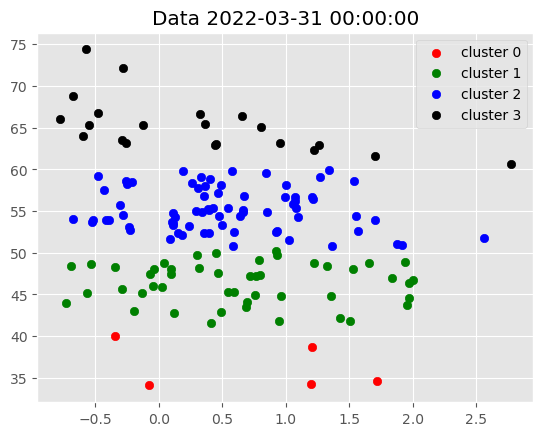

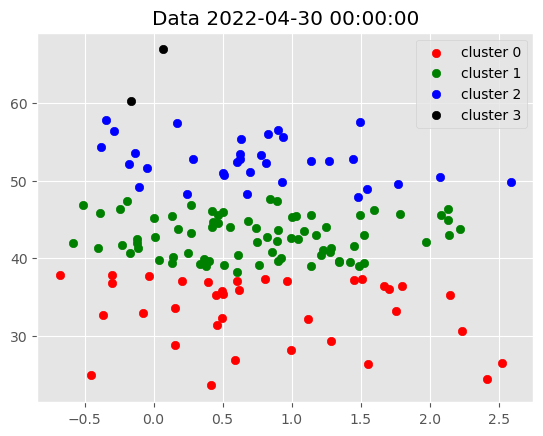

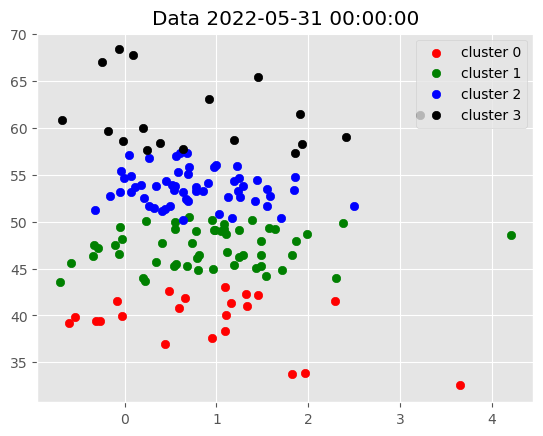

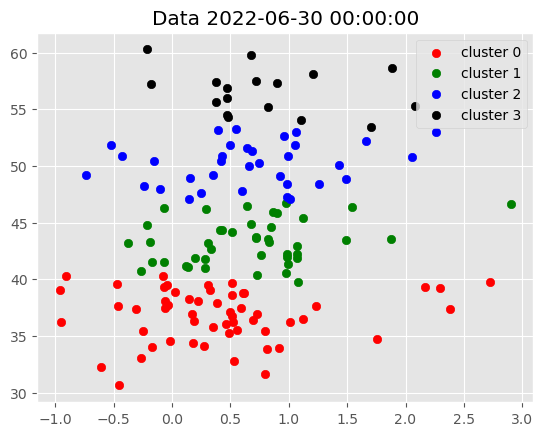

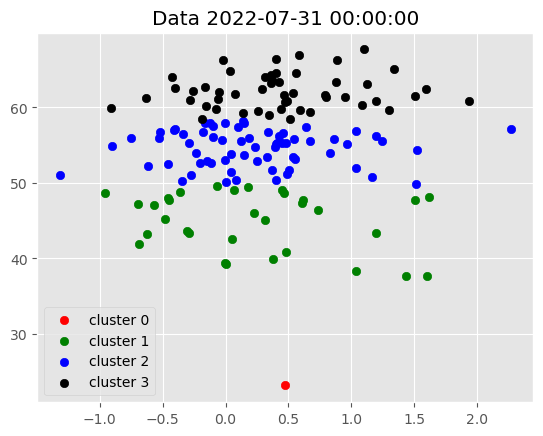

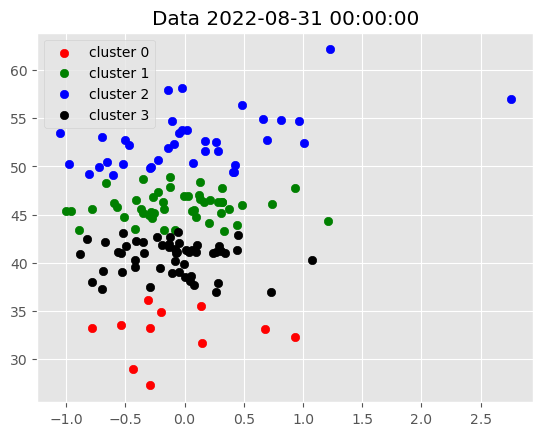

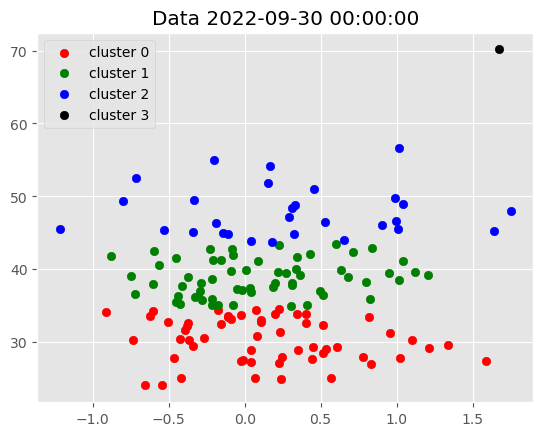

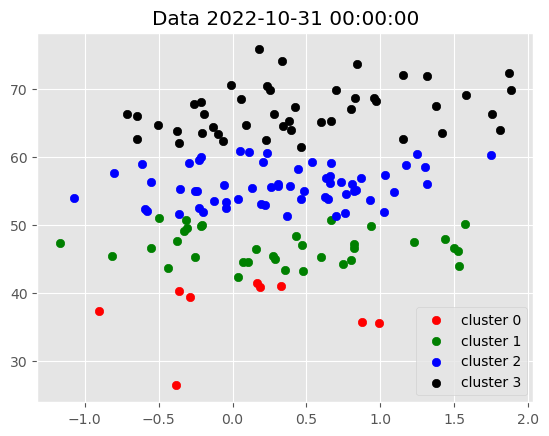

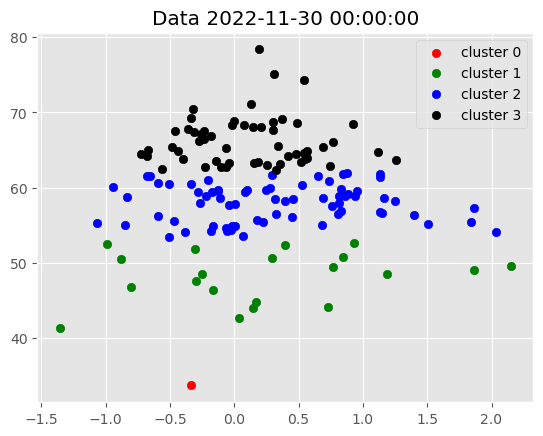

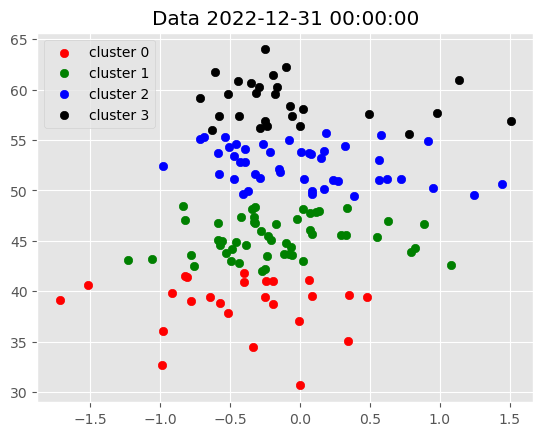

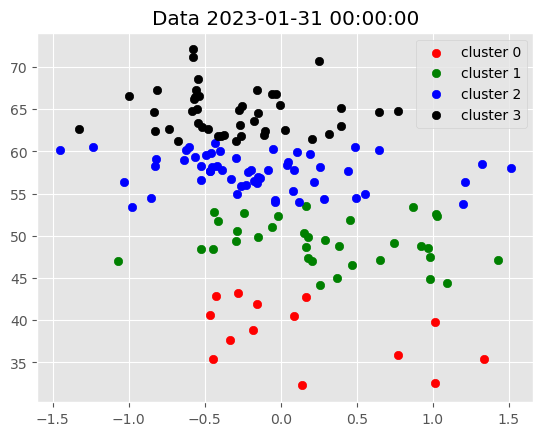

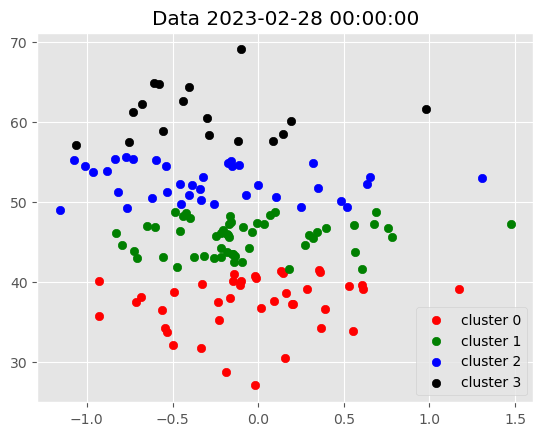

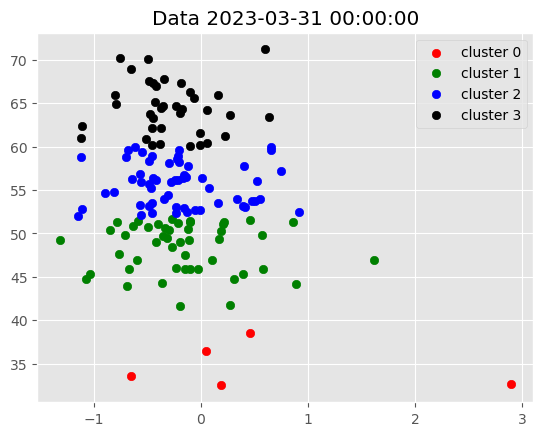

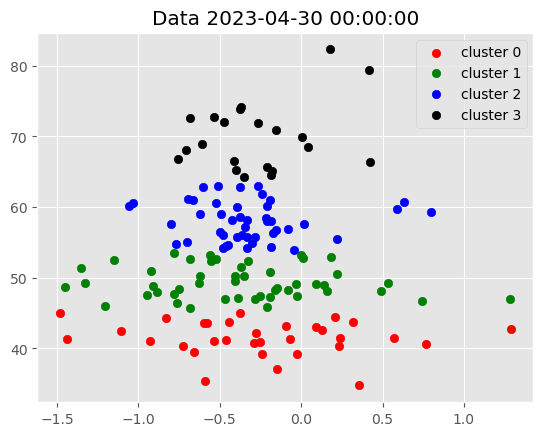

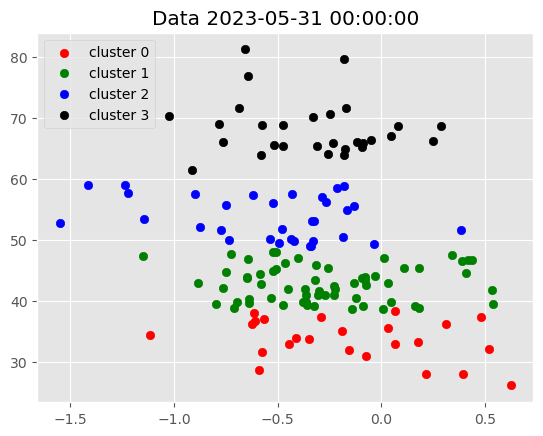

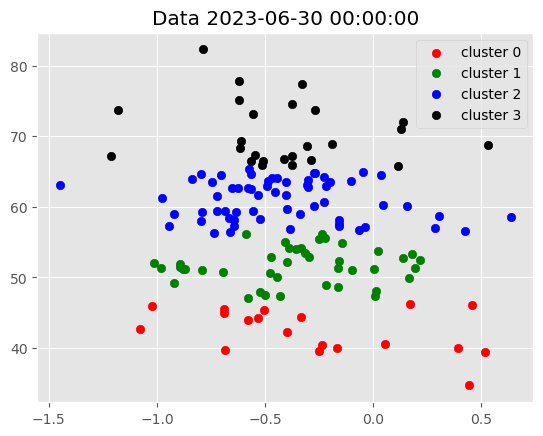

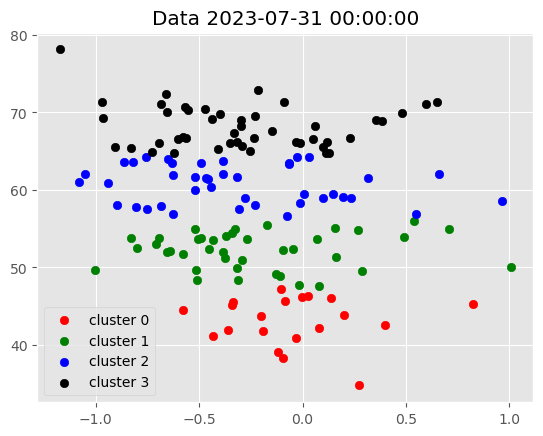

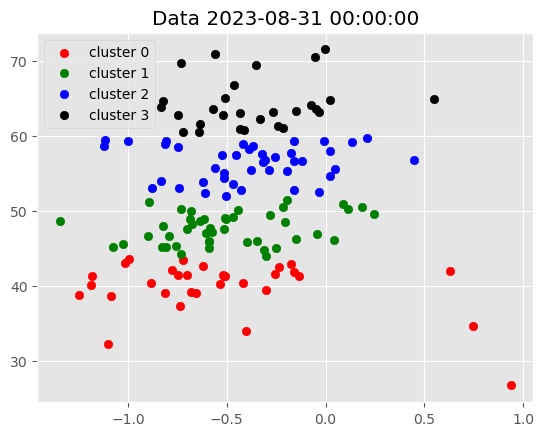

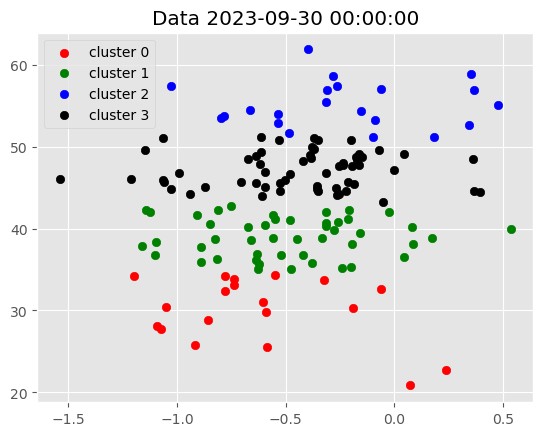

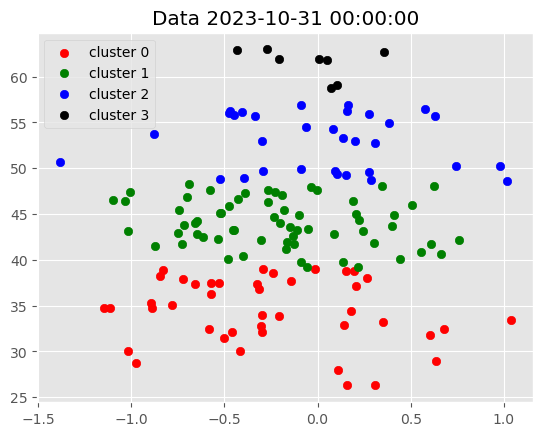

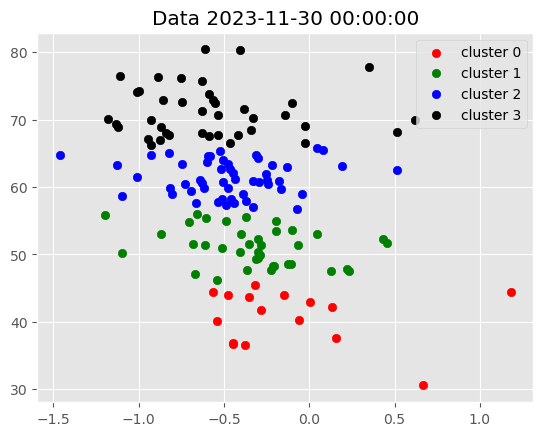

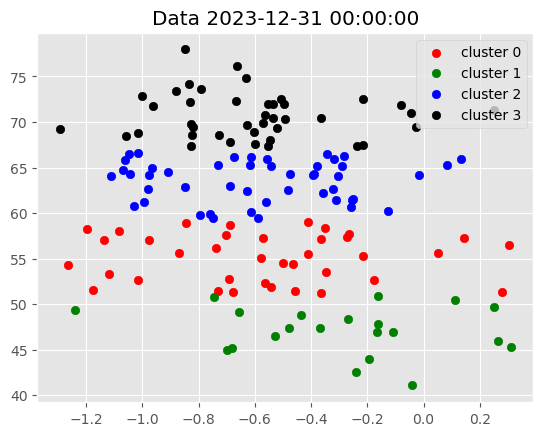

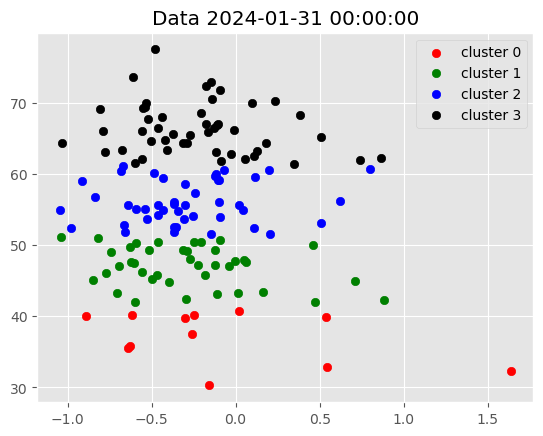

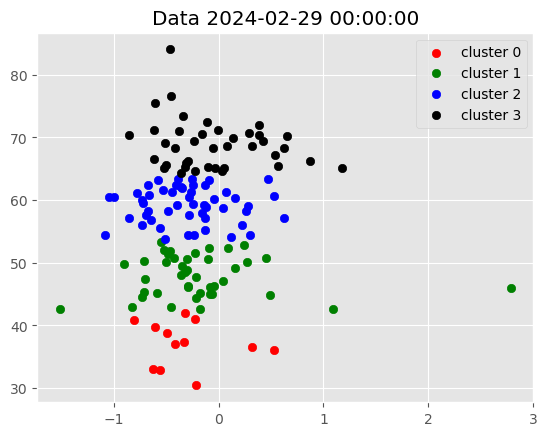

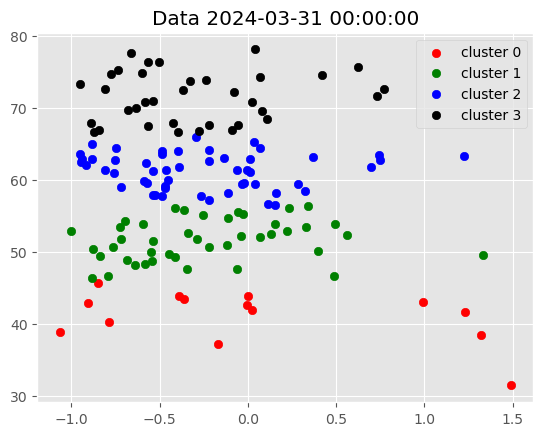

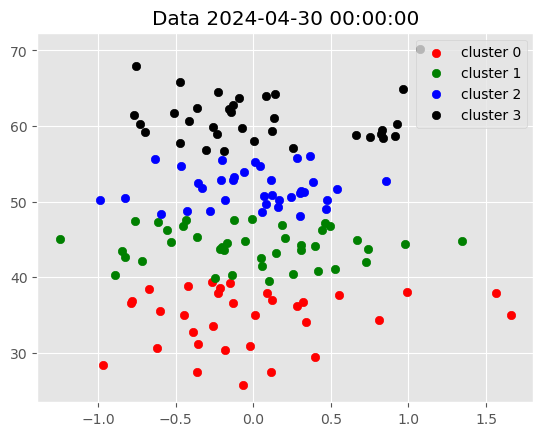

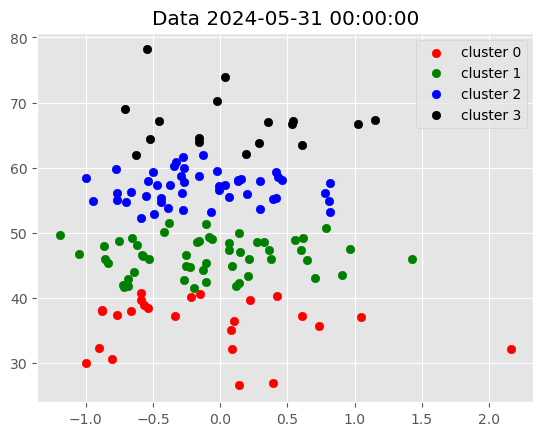

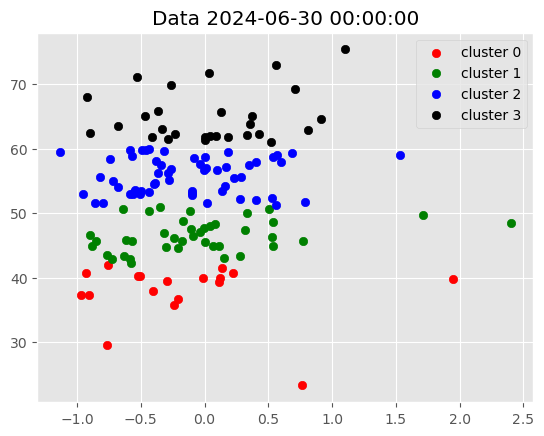

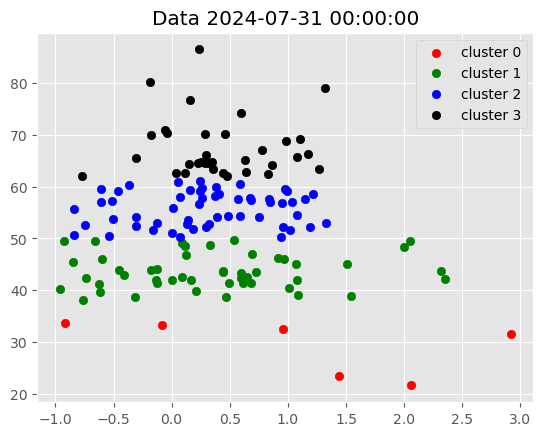

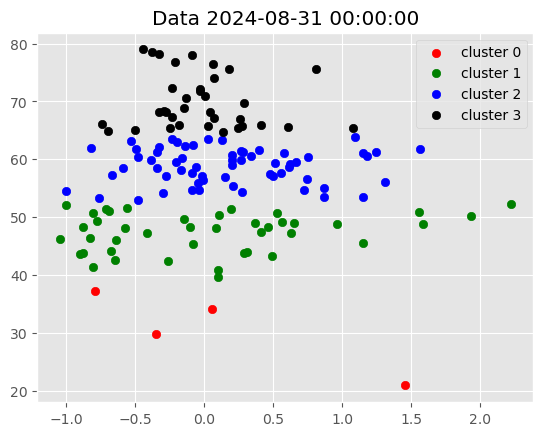

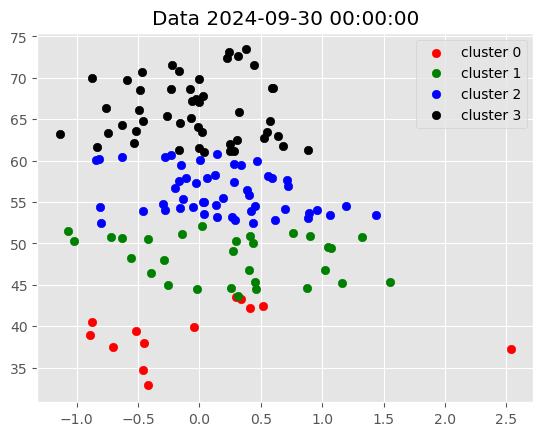

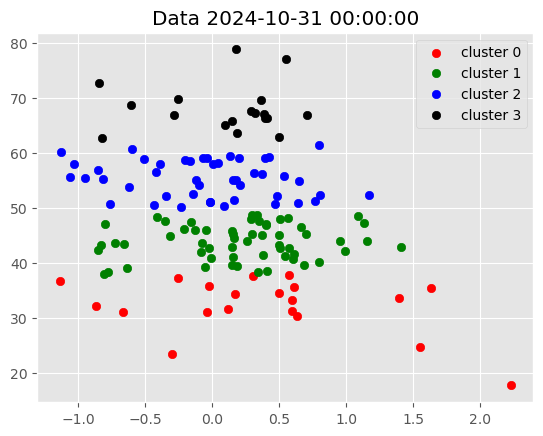

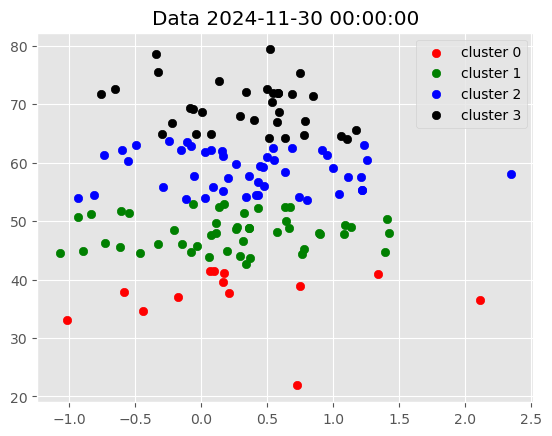

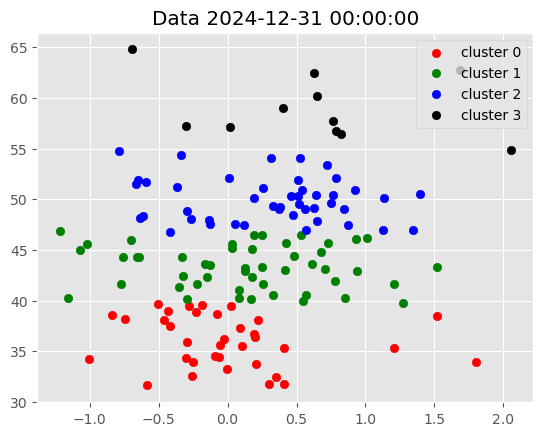

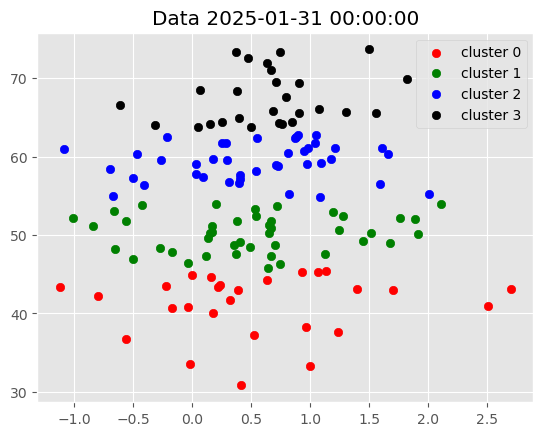

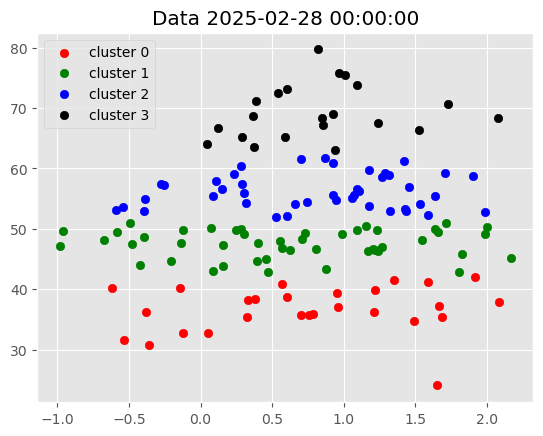

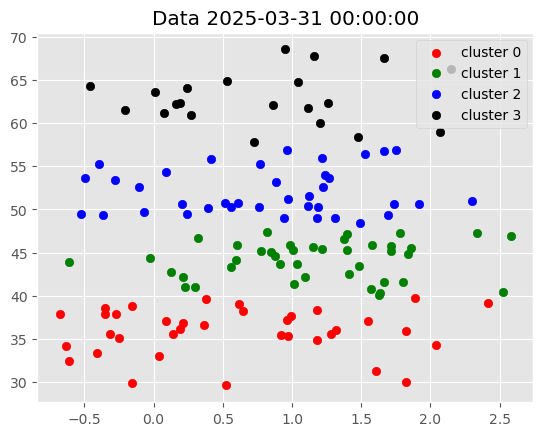

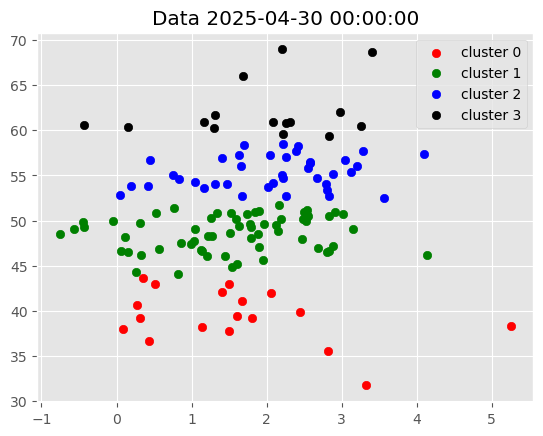

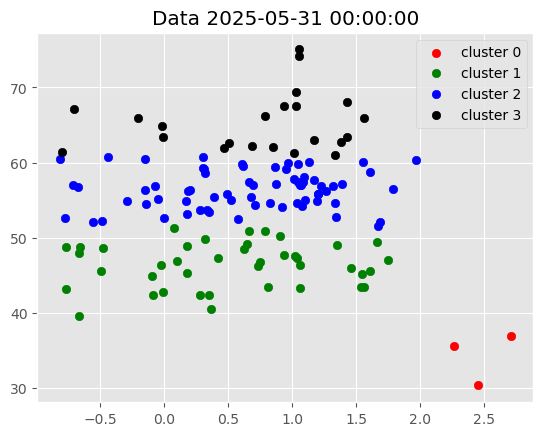

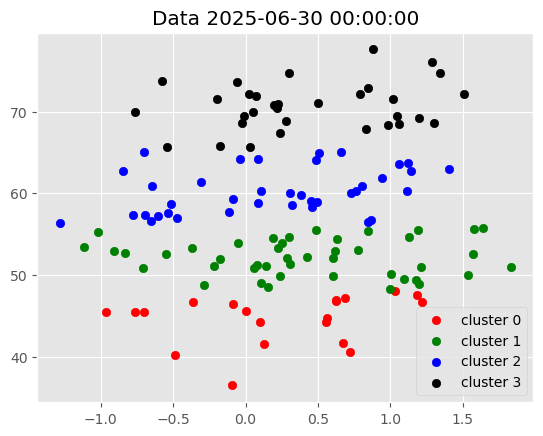

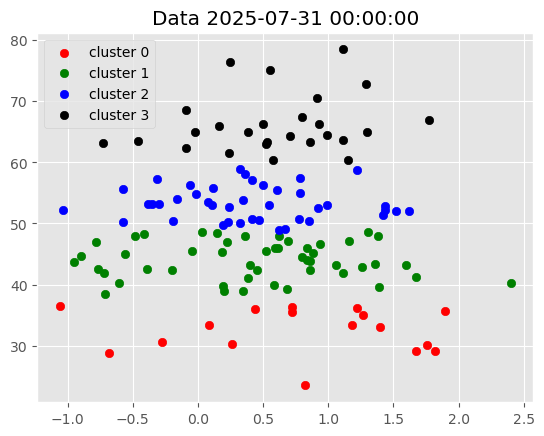

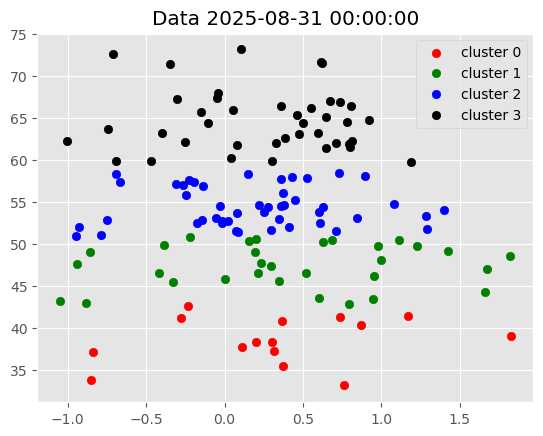

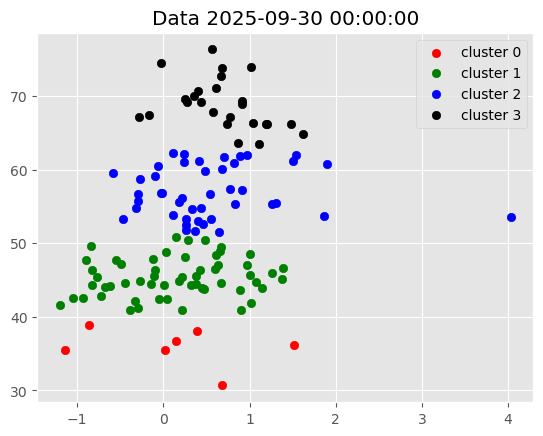

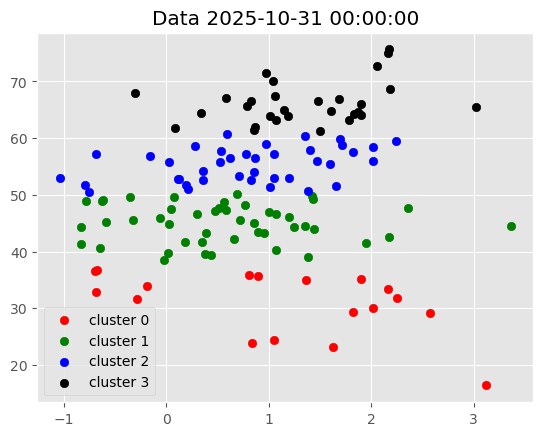

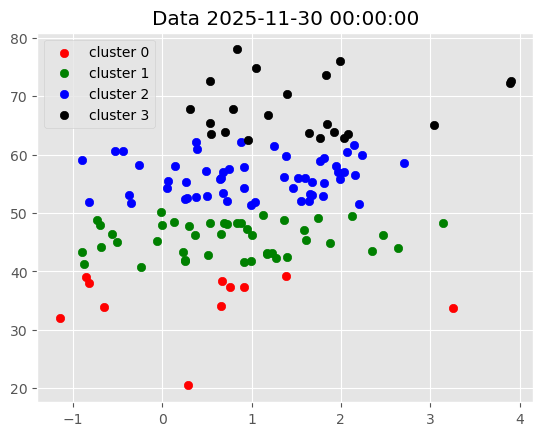

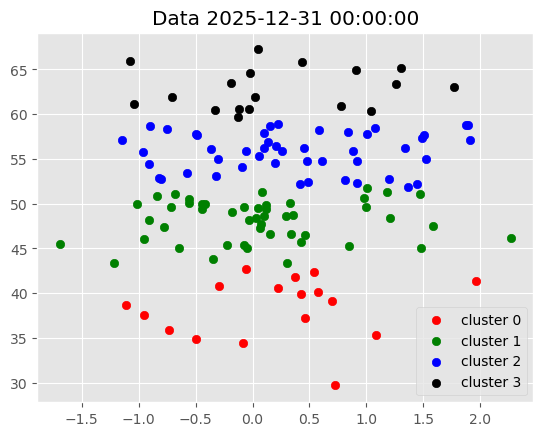

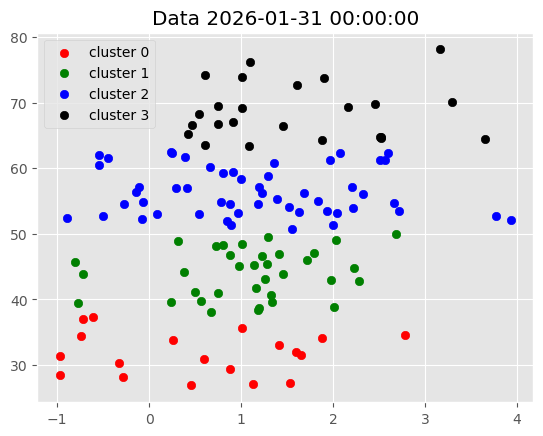

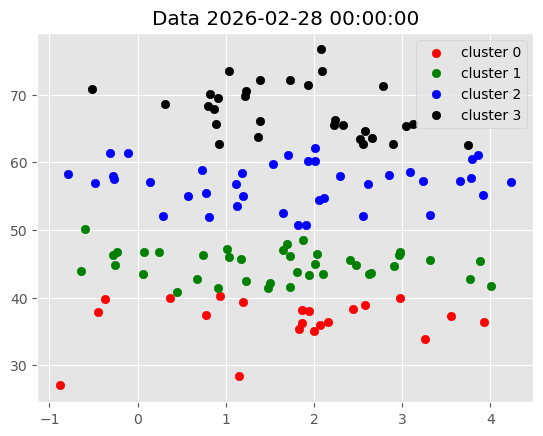

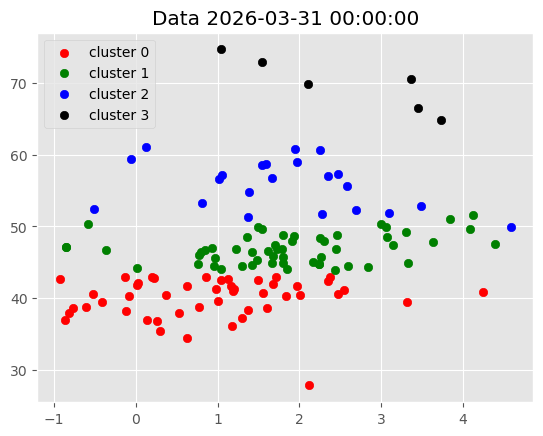

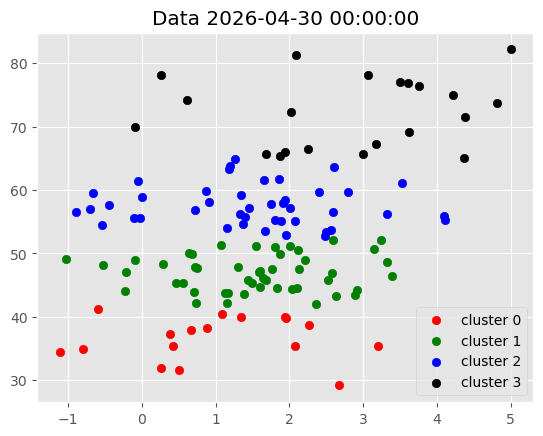

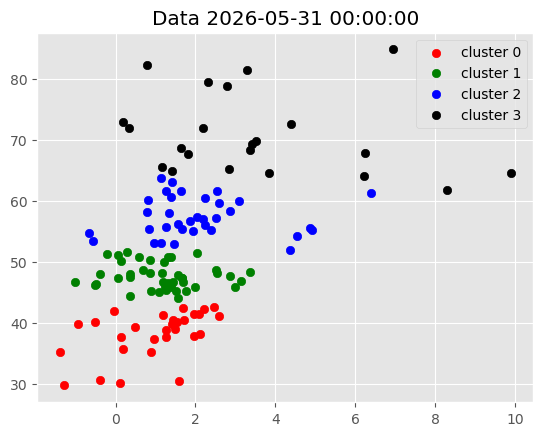

In [92]:
plt.style.use('ggplot')

for i in data.index.get_level_values('Date').unique().tolist():
    g = data.xs(i, level=0)
    plt.title(f'Data {i}')
    plot_clusters(g)

## Step 2: Choose assets for each month based on cluster and form a portfolio based on Efficient Frontier max Sharpe ratio Optimization

### Need this to have a good risk profile for the portfolio we build, we also balance asset weights that can yield us highest returns as well

In [93]:
filtered_df = data[data['cluster']==3].copy()

filtered_df

rsi    bb_low    bb_mid   bb_high       atr  \
Date       Ticker                                                      
2019-06-30 ABT     64.665798  4.233351  4.295571  4.357792 -1.417181   
           AMAT    60.826288  3.628134  3.698522  3.768910 -1.051045   
           AMGN    60.742299  4.930678  4.982496  5.034314 -1.411659   
           AXP     59.981480  4.675094  4.720688  4.766281 -1.217538   
           BLK     61.381313  5.884352  5.945096  6.005840 -1.297832   
...                      ...       ...       ...       ...       ...   
2026-05-31 PM      68.358841  5.024902  5.154942  5.284982  3.375773   
           QCOM    64.010801  4.832375  5.184717  5.537060  6.218022   
           TXN     72.555218  5.486398  5.638572  5.790747  4.399166   
           UNH     73.008148  5.834385  5.923072  6.011758  0.197120   
           UNP     65.625425  5.539375  5.585436  5.631498  1.159380   

                       macd  garman_klass_vol  return_1m  return_2m  \
Date       Ticker                                                     
2019-06-30 ABT     0.947063          0.000088   0.104689   0.028136   
           AMAT   -0.123805          0.000115   0.160765   0.012064   
           AMGN    0.442849          0.000087   0.105459   0.018090   
           AXP     0.182684          0.000041   0.076105   0.026145   
           BLK     0.268189          0.000103   0.137962  -0.012806   
...                     ...               ...        ...        ...   
2026-05-31 PM      3.982471          0.000304   0.160114   0.076206   
           QCOM    5.624415          0.003541   0.133979   0.257498   
           TXN     6.239404          0.000768   0.074880   0.203655   
           UNH     2.523318          0.000245   0.055738   0.191963   
           UNP     1.409133          0.000225   0.020966   0.064892   

                   return_3m  return_6m  return_9m  return_12m    Mkt-RF  \
Date       Ticker                                                          
2019-06-30 ABT      0.018439   0.026936   0.016743    0.028618  0.796026   
           AMAT     0.044084   0.055883   0.018607   -0.000642  1.455048   
           AMGN    -0.007270  -0.006409  -0.010437    0.002364  0.716482   
           AXP      0.042614   0.045354   0.017815    0.020677  1.162087   
           BLK      0.034314   0.032705   0.002065   -0.002663  1.291410   
...                      ...        ...        ...         ...       ...   
2026-05-31 PM       0.011255   0.036234   0.018325    0.007820  0.568011   
           QCOM     0.129150   0.034473   0.028601    0.030575  1.196136   
           TXN      0.115291   0.101154   0.047261    0.044702  0.942208   
           UNH      0.103585   0.031329   0.028581    0.024181  0.485041   
           UNP      0.012609   0.030847   0.024582    0.019638  0.981104   

                        SMB       HML       RMW       CMA  cluster  
Date       Ticker                                                   
2019-06-30 ABT    -0.181598 -0.106873 -0.103314  0.842086        3  
           AMAT    0.333425  0.147138  0.107059 -0.717216        3  
           AMGN   -0.266875  0.511689  0.738336  0.409633        3  
           AXP     0.006483  0.549171 -0.703689 -0.180358        3  
           BLK     0.098152  0.142464 -0.151182  0.217007        3  
...                     ...       ...       ...       ...      ...  
2026-05-31 PM     -0.089247  0.439774  0.204774  0.581617        3  
           QCOM    0.296332  0.071287  0.802592 -0.400299        3  
           TXN     0.367571  0.011668  0.460502  0.372383        3  
           UNH    -0.014556  0.505259  0.428226 -0.383905        3  
           UNP    -0.056440  0.217086 -0.021252  0.041923        3  

[2354 rows x 19 columns]

In [123]:
#filtered_df = filtered_df.reset_index(level=1)

# filtered_df
# filtered_df.index = filtered_df.index + pd.DateOffset(1)

# filtered_df = filtered_df.reset_index().set_index(['Date', 'Ticker'])

# dates = filtered_df.index.get_level_values('Date').unique().tolist()

# fixed_dates = {}

# for d in dates:
#     fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()

fixed_dates


{'2019-07-01': ['ABT',
  'AMAT',
  'AMGN',
  'AXP',
  'BLK',
  'BRK-B',
  'BSX',
  'C',
  'CAT',
  'CHTR',
  'COST',
  'DE',
  'DHR',
  'EA',
  'EBAY',
  'GM',
  'GS',
  'HD',
  'HON',
  'LMT',
  'MCD',
  'MDT',
  'META',
  'MPC',
  'NOC',
  'ORCL',
  'SBUX',
  'T',
  'TGT',
  'TMO',
  'V',
  'VLO',
  'WMT'],
 '2019-08-01': ['AAPL',
  'ABT',
  'AMAT',
  'AMGN',
  'BAC',
  'CMG',
  'COST',
  'EBAY',
  'GM',
  'GOOG',
  'GOOGL',
  'GS',
  'IBM',
  'JPM',
  'LRCX',
  'LULU',
  'MDT',
  'MU',
  'NOC',
  'PANW',
  'PG',
  'SBUX',
  'SHW',
  'T',
  'TXN',
  'UNP',
  'WDC',
  'XYZ'],
 '2019-09-01': ['AMGN',
  'AMT',
  'CHTR',
  'CMG',
  'COST',
  'CVS',
  'HD',
  'INTU',
  'KO',
  'LMT',
  'LOW',
  'MDT',
  'NEE',
  'NOC',
  'PEP',
  'SHW',
  'T',
  'TGT',
  'UPS',
  'WMT'],
 '2019-10-01': ['AAPL',
  'ABBV',
  'BMY',
  'DE',
  'HD',
  'IBM',
  'MPC',
  'NEE',
  'NKE',
  'PG',
  'SHW',
  'T',
  'TGT',
  'VZ',
  'WFC',
  'WMT'],
 '2019-11-01': ['AAPL',
  'ABBV',
  'ALGN',
  'AMD',
  'AMGN',
  '

## Step 3: Defining portfolio Optimization function

In [139]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):

    rets = expected_returns.mean_historical_return(prices=prices,
                                                   frequency=252)
    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)
    
    ef = EfficientFrontier(expected_returns=rets,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')

    weights = ef.max_sharpe()

    return ef.clean_weights()

## Step 4: Download fresh price data as we need atleast 1 year of price data for each month of stock lists

In [99]:
stocks = data.index.get_level_values('Ticker').unique().tolist()

new_df = yf.download(tickers=stocks,
                     start=data.index.get_level_values('Date').unique()[0] - pd.DateOffset(months=12),
                     end=data.index.get_level_values('Date').unique()[-1])

new_df

[*********************100%***********************]  153 of 153 completed


Price            Close                                                 \
Ticker            AAPL        ABBV        ABNB        ABT         ACN   
Date                                                                    
2018-07-02   44.102535   66.214874         NaN  52.908745  145.101608   
2018-07-03   43.334438   66.570435         NaN  52.743946  145.199387   
2018-07-05   43.683151   67.189125         NaN  53.194977  146.497192   
2018-07-06   44.288681   68.924332         NaN  53.914883  146.239380   
2018-07-09   44.903625   69.009674         NaN  54.157738  147.679520   
...                ...         ...         ...        ...         ...   
2026-05-18  297.839996  209.410004  134.300003  87.910004  177.550003   
2026-05-19  298.970001  213.759995  131.160004  88.820000  176.800003   
2026-05-20  302.250000  212.300003  135.550003  88.379997  179.220001   
2026-05-21  304.989990  214.500000  134.250000  87.769997  177.869995   
2026-05-22  308.820007  215.699997  132.350006  87.410004  179.240005   

Price                                                                   ...  \
Ticker            ADBE         ADI         ADP        ADSK        ALGN  ...   
Date                                                                    ...   
2018-07-02  243.259995   83.609299  114.143501  131.899994  340.279999  ...   
2018-07-03  242.009995   82.046669  113.127846  131.600006  338.679993  ...   
2018-07-05  244.179993   83.687439  113.170181  132.800003  341.380005  ...   
2018-07-06  248.190002   84.381920  113.601822  135.110001  347.470001  ...   
2018-07-09  249.770004   84.364555  113.855751  134.970001  348.970001  ...   
...                ...         ...         ...         ...         ...  ...   
2026-05-18  255.639999  418.579987  222.940002  243.490005  158.779999  ...   
2026-05-19  254.990005  414.309998  220.440002  244.160004  155.160004  ...   
2026-05-20  253.369995  398.049988  220.690002  243.630005  163.380005  ...   
2026-05-21  244.100006  384.209991  220.080002  240.190002  163.039993  ...   
2026-05-22  244.759995  397.070007  225.309998  240.990005  163.610001  ...   

Price        Volume                                                            \
Ticker          VLO     VRTX        VZ      WDAY      WDC       WFC       WMT   
Date                                                                            
2018-07-02  3748500  2283600  13141200   1297000  3289640  21204900  24375300   
2018-07-03  2078100  1059900   8441100    935700  2466469  12830400  13188600   
2018-07-05  3400600  1178600  11279600   2573600  3423395  16788600  16102500   
2018-07-06  2461300  1518900  10203800   1929200  2959683  12389100  16841100   
2018-07-09  2726500  1334700  10491200   2956200  3588241  16684000  19726200   
...             ...      ...       ...       ...      ...       ...       ...   
2026-05-18  3255600  1451000  25427400   4611700  8996700  16934200  17183200   
2026-05-19  3842000  1219500  24593800   4478900  5891600  18649800  16957100   
2026-05-20  2959500  1784800  16714600   6060000  5311700  14695300  28471600   
2026-05-21  3610700  1395200  15841900   9182900  5046800   9433400  53006600   
2026-05-22  2490211  1708254  14614462  10772912  3816774   8727690  30276543   

Price                                    
Ticker         WYNN       XOM       XYZ  
Date                                     
2018-07-02  6755000   9998300   5427100  
2018-07-03  2227700   7197300   4234700  
2018-07-05  2626100   9035700   7671000  
2018-07-06  2048800   7637100  10441600  
2018-07-09  4568900   7158600   9067800  
...             ...       ...       ...  
2026-05-18  1341000  20065200   4806000  
2026-05-19  1002200  20715600   5723800  
2026-05-20  1550400  18509700   6427100  
2026-05-21   904000  17061700   8496800  
2026-05-22  1182077  12918163   4907562  

[1984 rows x 765 columns]

## Step 5: Build logic to map out normalized final returns from our trading strategy

In [224]:
#returns_dataframe = np.log(new_df['Close']).diff()

#returns_dataframe

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():
    try:
        end_date = (pd.to_datetime(start_date) + pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')
    
        cols = fixed_dates[start_date]
        
        optimization_start_date = (pd.to_datetime(start_date) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
        optimization_end_date = (pd.to_datetime(start_date) - pd.DateOffset(days=1)).strftime('%Y-%m-%d')
    
        optimization_df = new_df.loc[optimization_start_date:optimization_end_date]\
                         .xs('Close', axis=1, level=0)[cols]

        success = False
        try:        
            low_bound = round(1/(len(optimization_df.columns)*2),3)
        
            weights = optimize_weights(prices=optimization_df,
                                   lower_bound=low_bound)
        
            weights = pd.DataFrame(weights, index=pd.Series(0))
            success = True
        except:
            print(f'Max Sharpe Opt failed for {start_date}, continue with equal weights')

        if success == False:
            weights = pd.DataFrame([1/len(optimization_df.columns) for i in range(len(optimization_df.columns))],
                         index=optimization_df.columns.tolist(),
                         columns=pd.Series(0)).T
            
        temp_df = returns_dataframe[start_date:end_date]
    
        temp_df = temp_df.stack().to_frame('return').reset_index(level=0)\
        .merge(weights.stack().to_frame('weight').reset_index(level=0, drop=True),
               left_index=True,
               right_index=True)\
        .reset_index().set_index(['Date','Ticker']).unstack().stack()
        
        temp_df['weighted_return'] = temp_df['return'] * temp_df['weight']
    
        temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')
        
        portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)
        
    except Exception as e:
        print(e)

portfolio_df = portfolio_df.drop_duplicates()
       

Max Sharpe Opt failed for 2020-03-01, continue with equal weights
Max Sharpe Opt failed for 2020-04-01, continue with equal weights
Max Sharpe Opt failed for 2021-02-01, continue with equal weights
Max Sharpe Opt failed for 2021-10-01, continue with equal weights
Max Sharpe Opt failed for 2022-05-01, continue with equal weights
Max Sharpe Opt failed for 2022-09-01, continue with equal weights
Max Sharpe Opt failed for 2022-10-01, continue with equal weights
Max Sharpe Opt failed for 2023-11-01, continue with equal weights
Max Sharpe Opt failed for 2026-04-01, continue with equal weights
'return'


<Axes: xlabel='Date'>

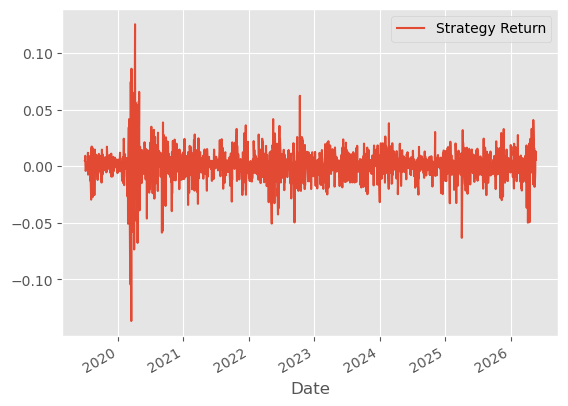

In [225]:
portfolio_df.plot()

## Step 6: Compare our returns to the S&P500 returns

In [235]:
spy = yf.download(tickers='SPY',
                  start='2019-06-30',
                  end=dt.date.today())

spy_ret = np.log(spy[['Close']]).diff().dropna().rename({'Close': 'SPY Buy&Hold'}, axis = 1)

spy_ret.columns = spy_ret.columns.droplevel(0)
spy_ret

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2019-07-02,0.002601
2019-07-03,0.007964
2019-07-05,-0.001139
2019-07-08,-0.005510
2019-07-09,0.001246
...,...
2026-05-15,-0.012102
2026-05-18,-0.000704
2026-05-19,-0.006683


In [236]:
portfolio_df = portfolio_df.merge(spy_ret,
                                  left_index=True,
                                  right_index=True)


In [237]:
portfolio_df

,Strategy Return,SPY
Date,,
2019-07-02,0.004626,0.002601
2019-07-03,0.009169,0.007964
2019-07-05,-0.004149,-0.001139
2019-07-08,-0.002755,-0.005510
2019-07-09,-0.000085,0.001246
...,...,...
2026-05-15,-0.018222,-0.012102
2026-05-18,-0.010282,-0.000704
2026-05-19,-0.004393,-0.006683


In [238]:
plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())-1


,Strategy Return,SPY
Date,,
2019-07-02,0.004626,0.002601
2019-07-03,0.013838,0.010585
2019-07-05,0.009631,0.009434
2019-07-08,0.006849,0.003872
2019-07-09,0.006764,0.005123
...,...,...
2026-05-15,0.957475,1.406706
2026-05-18,0.937348,1.405013
2026-05-19,0.928838,1.388940


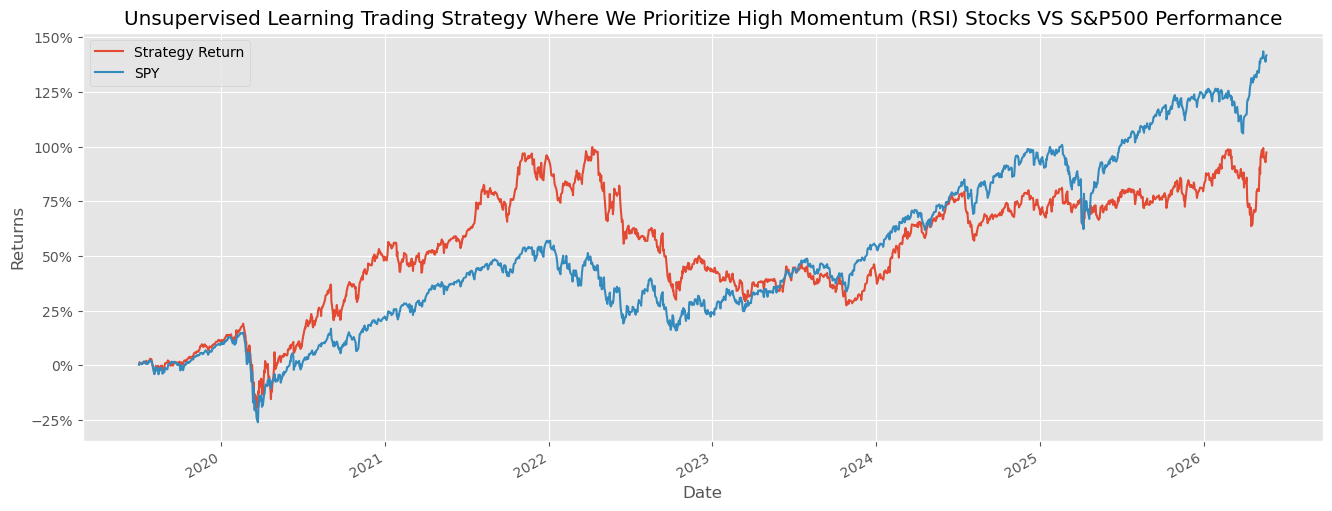

In [245]:
import matplotlib.ticker as mtick

portfolio_cumulative_return[:'2026-05-21'].plot(figsize=(16,6))
plt.title('Unsupervised Learning Trading Strategy Where We Prioritize High Momentum (RSI) Stocks VS S&P500 Performance')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.ylabel('Returns')
plt.show()

### Custom momentum-based trading strategy outperformed S&P500 until mid-2023 but still is fairly profitable later on